Load Libraries

In [1]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.applications.resnet50 import decode_predictions
from tensorflow.keras.applications.resnet50 import preprocess_input
import tensorflow as tf
import numpy as np
import argparse
import cv2
import pandas as pd
import pickle
import copy 
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

Generate Targeted Adversary

In [2]:
def generate_targeted_adversaries(model, baseImage, delta, classIdx,
    target, steps=40):
    # iterate over the number of steps
    y_orinal = tf.keras.utils.to_categorical(classIdx, num_classes)
    y_target = tf.keras.utils.to_categorical(target, num_classes)
    for step in range(0, steps):
        # record our gradients
        with tf.GradientTape() as tape:
            # explicitly indicate that our perturbation vector should
            # be tracked for gradient updates
            tape.watch(delta)

            # add our perturbation vector to the base image and
            # preprocess the resulting image
            adversary = baseImage + delta

            # run this newly constructed image tensor through our
            # model and calculate the loss with respect to the
            # both the *original* class label and the *target*
            # class label
            
            predictions = tf.transpose(model(adversary, training=False))
            originalLoss = -sccLoss(tf.convert_to_tensor(y_orinal),
                predictions)
            
            targetLoss = sccLoss(tf.convert_to_tensor(y_target),
                predictions)
            totalLoss = originalLoss + targetLoss

            # check to see if we are logging the loss value, and if
            # so, display it to our terminal
            if step % 10 == 0:
                print("step: {}, loss: {}...".format(step,totalLoss.numpy()))

        # calculate the gradients of loss with respect to the
        # perturbation vector
        gradients = tape.gradient(totalLoss, delta)

        # update the weights, clip the perturbation vector, and
        # update its value
        optimizer.apply_gradients([(gradients, delta)])
#         print(delta)
#         delta.assign_add(clip_eps(delta, eps=EPS))
        x_test_1 = baseImage + delta
        predicted_y = model.predict_classes(x_test_1, batch_size=32, verbose=0)
        if predicted_y[0] == target:
            print("step: {}, loss: {}...".format(step,totalLoss.numpy()))
            break;
        

    # return the perturbation vector
    return delta

Load Model

In [3]:
model = tf.keras.models.load_model("./data/last-model.h5")
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 650)               195650    
_________________________________________________________________
batch_normalization_1 (Batch (None, 650)               2600      
_________________________________________________________________
activation_1 (Activation)    (None, 650)               0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 650)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 600)               390600    
_________________________________________________________________
batch_normalization_2 (Batch (None, 600)               2400      
_________________________________________________________________
activation_2 (Activation)    (None, 600)               0

Load Pickle file

In [4]:
with open('./data/dictionary.pkl', 'rb') as f:
    num_classes = pickle.load(f)
    X_min = pickle.load(f)
    X_max = pickle.load(f)
    ipca=pickle.load(f)

Read the transformed input

In [5]:
X_poj = pd.read_csv('./csv_data/POJ_104.csv', sep='\t',header=None)
Y_poj = X_poj.loc[:,0]
X_poj = X_poj.loc[:,1:300]
X_poj.columns = range(X_poj.shape[1])
x_poj = (X_poj - X_min) / (X_max - X_min)
x_poj = np.array(x_poj)
x_poj = ipca.transform(x_poj)
Y_poj = np.array(Y_poj)
Y_poj = Y_poj - 1



X_adce = pd.read_csv('./csv_data/POJ_104_adce.csv', sep='\t',header=None)
Y_adce = X_adce.loc[:,0]
X_adce = X_adce.loc[:,1:300]
X_adce.columns = range(X_adce.shape[1])
x_adce = (X_adce - X_min) / (X_max - X_min)
x_adce = np.array(x_adce)
x_adce = ipca.transform(x_adce)
Y_adce = np.array(Y_adce)
Y_adce = Y_adce - 1

X_mem2reg = pd.read_csv('./csv_data/POJ_104_mem2reg.csv', sep='\t',header=None)
Y_mem2reg = X_mem2reg.loc[:,0]
X_mem2reg = X_mem2reg.loc[:,1:300]
X_mem2reg.columns = range(X_mem2reg.shape[1])
x_mem2reg = (X_mem2reg - X_min) / (X_max - X_min)
x_mem2reg = np.array(x_mem2reg)
x_mem2reg = ipca.transform(x_mem2reg)
Y_mem2reg = np.array(Y_mem2reg)
Y_mem2reg = Y_mem2reg - 1

X_loop_rotate = pd.read_csv('./csv_data/POJ_104_loop_rotate.csv', sep='\t',header=None)
Y_loop_rotate = X_loop_rotate.loc[:,0]
X_loop_rotate = X_loop_rotate.loc[:,1:300]
X_loop_rotate.columns = range(X_loop_rotate.shape[1])
x_loop_rotate = (X_loop_rotate - X_min) / (X_max - X_min)
x_loop_rotate = np.array(x_loop_rotate)
x_loop_rotate = ipca.transform(x_loop_rotate)
Y_loop_rotate = np.array(Y_loop_rotate)
Y_loop_rotate = Y_loop_rotate - 1

X_loop_simplify = pd.read_csv('./csv_data/POJ_104_loop_simplify.csv', sep='\t',header=None)
Y_loop_simplify = X_loop_simplify.loc[:,0]
X_loop_simplify = X_loop_simplify.loc[:,1:300]
X_loop_simplify.columns = range(X_loop_simplify.shape[1])
x_loop_simplify = (X_loop_simplify - X_min) / (X_max - X_min)
x_loop_simplify = np.array(x_loop_simplify)
x_loop_simplify = ipca.transform(x_loop_simplify)
Y_loop_simplify = np.array(Y_loop_simplify)
Y_loop_simplify = Y_loop_simplify - 1

X_loop_unroll = pd.read_csv('./csv_data/POJ_104_loop_unroll.csv', sep='\t',header=None)
Y_loop_unroll = X_loop_unroll.loc[:,0]
X_loop_unroll = X_loop_unroll.loc[:,1:300]
X_loop_unroll.columns = range(X_loop_unroll.shape[1])
x_loop_unroll = (X_loop_unroll - X_min) / (X_max - X_min)
x_loop_unroll = np.array(x_loop_unroll)
x_loop_unroll = ipca.transform(x_loop_unroll)
Y_loop_unroll = np.array(Y_loop_unroll)
Y_loop_unroll = Y_loop_unroll - 1

X_loop_vectorize = pd.read_csv('./csv_data/POJ_104_loop_vectorize.csv', sep='\t',header=None)
Y_loop_vectorize = X_loop_vectorize.loc[:,0]
X_loop_vectorize = X_loop_vectorize.loc[:,1:300]
X_loop_vectorize.columns = range(X_loop_vectorize.shape[1])
x_loop_vectorize = (X_loop_vectorize - X_min) / (X_max - X_min)
x_loop_vectorize = np.array(x_loop_vectorize)
x_loop_vectorize = ipca.transform(x_loop_vectorize)
Y_loop_vectorize = np.array(Y_loop_vectorize)
Y_loop_vectorize = Y_loop_vectorize - 1

X_memoryssa = pd.read_csv('./csv_data/POJ_104_memoryssa.csv', sep='\t',header=None)
Y_memoryssa = X_memoryssa.loc[:,0]
X_memoryssa = X_memoryssa.loc[:,1:300]
X_memoryssa.columns = range(X_memoryssa.shape[1])
x_memoryssa = (X_memoryssa - X_min) / (X_max - X_min)
x_memoryssa = np.array(x_memoryssa)
x_memoryssa = ipca.transform(x_memoryssa)
Y_memoryssa = np.array(Y_memoryssa)
Y_memoryssa = Y_memoryssa - 1

X_simplifycfg = pd.read_csv('./csv_data/POJ_104_simplifycfg.csv', sep='\t',header=None)
Y_simplifycfg = X_simplifycfg.loc[:,0]
X_simplifycfg = X_simplifycfg.loc[:,1:300]
X_simplifycfg.columns = range(X_simplifycfg.shape[1])
x_simplifycfg = (X_simplifycfg - X_min) / (X_max - X_min)
x_simplifycfg = np.array(x_simplifycfg)
x_simplifycfg = ipca.transform(x_simplifycfg)
Y_simplifycfg = np.array(Y_simplifycfg)
Y_simplifycfg = Y_simplifycfg - 1

Predict class label for transformations using the trained model and save the index of correct labels

In [6]:
pred_poj =  model.predict_classes(x_poj, verbose=0)
poj_correct=[]
for i in range(len(pred_poj)):
    if pred_poj[i]==Y_poj[i]:
        poj_correct.append(i)

len(poj_correct)

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


38820

Shffle data

In [7]:
# Shuffle the input
shuffled_index=copy.deepcopy(poj_correct[:30000])

np.random.shuffle(shuffled_index)

In [8]:
subsetsize=2000

Analysis 1-- Finding the distance between correct classified example (transformed) and adversarial example

Find adversarial example of input for which transformation is predicted correctly

In [9]:
EPS = 2 / 255.0
LR = 5e-5

optimizer = Adam(lr=LR,beta_1=0.9, beta_2=0.999, epsilon=None,decay=0.0, amsgrad=False)
sccLoss = CategoricalCrossentropy()

Find adversarial example (random target)

In [11]:

initial_adversaries=[]
increment_value = 10
baseImage = tf.constant(x_poj[0:0+1], dtype=tf.float32)
delta = tf.Variable(tf.zeros_like(baseImage), trainable=True)
for i in range(subsetsize):
    print(i)
    index=shuffled_index[i]
    baseImage = tf.constant(x_poj[index:index+1], dtype=tf.float32)
    delta = tf.Variable(tf.zeros_like(baseImage), trainable=True)
    targer = (Y_poj[index] + increment_value)%104
    deltaUpdated = generate_targeted_adversaries(model, baseImage, delta,Y_poj[index], targer)
    initial_adversaries.append(deltaUpdated)

0
step: 0, loss: 14.100707054138184...
step: 10, loss: -5.226567268371582...
step: 17, loss: -14.203715324401855...
1
step: 0, loss: 12.17922592163086...
step: 9, loss: -14.126307487487793...
2
step: 0, loss: 16.1180362701416...
step: 9, loss: -14.526144981384277...
3
step: 0, loss: 12.40069580078125...
step: 10, loss: -4.986794471740723...
step: 20, loss: -12.495955467224121...
step: 29, loss: -15.167893409729004...
4
step: 0, loss: 7.970059394836426...
step: 1, loss: 1.5490236282348633...
5
step: 0, loss: 15.297601699829102...
step: 10, loss: -8.424657821655273...
step: 20, loss: -12.149165153503418...
step: 24, loss: -14.966670036315918...
6
step: 0, loss: 11.954174041748047...
step: 10, loss: -6.509415626525879...
step: 20, loss: -11.761326789855957...
step: 27, loss: -14.992355346679688...
7
step: 0, loss: 9.913734436035156...
step: 2, loss: 3.2419650554656982...
8
step: 0, loss: 16.11802864074707...
step: 6, loss: -13.889850616455078...
9
step: 0, loss: 9.046768188476562...
step:

step: 4, loss: -7.869318962097168...
79
step: 0, loss: 14.005931854248047...
step: 10, loss: 0.0...
step: 20, loss: 0.0...
step: 30, loss: 0.0...
80
step: 0, loss: 8.335104942321777...
step: 7, loss: -14.284531593322754...
81
step: 0, loss: 10.356236457824707...
step: 8, loss: -14.395520210266113...
82
step: 0, loss: 16.08435821533203...
step: 10, loss: -8.845842361450195...
step: 17, loss: -14.552290916442871...
83
step: 0, loss: 11.088465690612793...
step: 10, loss: -11.654138565063477...
step: 14, loss: -14.251191139221191...
84
step: 0, loss: 10.132315635681152...
step: 2, loss: -11.822874069213867...
85
step: 0, loss: 12.843432426452637...
step: 10, loss: 0.0...
step: 20, loss: 0.0...
step: 30, loss: 0.0...
86
step: 0, loss: 11.072615623474121...
step: 5, loss: -14.32728385925293...
87
step: 0, loss: 13.760188102722168...
step: 2, loss: -6.376531600952148...
88
step: 0, loss: 15.81983470916748...
step: 10, loss: -12.421968460083008...
step: 11, loss: -14.523550033569336...
89
step

step: 10, loss: -13.769063949584961...
step: 12, loss: -14.739750862121582...
239
step: 0, loss: 11.829328536987305...
step: 10, loss: -13.864563941955566...
step: 11, loss: -14.292848587036133...
240
step: 0, loss: 11.363645553588867...
step: 10, loss: -7.671703815460205...
step: 20, loss: -13.638920783996582...
step: 26, loss: -14.83729362487793...
241
step: 0, loss: 15.504013061523438...
step: 1, loss: -3.574148178100586...
242
step: 0, loss: 15.882760047912598...
step: 7, loss: -14.96873664855957...
243
step: 0, loss: 14.87838077545166...
step: 10, loss: -13.265985488891602...
step: 11, loss: -14.296366691589355...
244
step: 0, loss: 12.1309175491333...
step: 6, loss: -12.355888366699219...
245
step: 0, loss: 14.5764741897583...
step: 9, loss: -14.267145156860352...
246
step: 0, loss: 14.380590438842773...
step: 2, loss: -2.6932895183563232...
247
step: 0, loss: 13.224658966064453...
step: 0, loss: 13.224658966064453...
248
step: 0, loss: 13.913854598999023...
step: 1, loss: 1.3955

step: 11, loss: -14.196091651916504...
325
step: 0, loss: 8.645299911499023...
step: 3, loss: -6.400732040405273...
326
step: 0, loss: 12.301756858825684...
step: 6, loss: -14.625633239746094...
327
step: 0, loss: 16.118087768554688...
step: 10, loss: -8.593406677246094...
step: 16, loss: -14.693828582763672...
328
step: 0, loss: 16.118066787719727...
step: 10, loss: 0.0...
step: 20, loss: 0.0...
step: 30, loss: 0.0...
329
step: 0, loss: 16.025390625...
step: 6, loss: -11.063228607177734...
330
step: 0, loss: 13.633463859558105...
step: 10, loss: -10.820348739624023...
step: 12, loss: -14.822250366210938...
331
step: 0, loss: 16.11760711669922...
step: 10, loss: -12.65138053894043...
step: 11, loss: -13.875627517700195...
332
step: 0, loss: 16.118093490600586...
step: 9, loss: -15.038005828857422...
333
step: 0, loss: 16.11808204650879...
step: 5, loss: -10.249592781066895...
334
step: 0, loss: 10.732415199279785...
step: 10, loss: -12.898355484008789...
step: 13, loss: -14.83224296569

step: 26, loss: -14.518333435058594...
412
step: 0, loss: 16.118061065673828...
step: 5, loss: -13.390968322753906...
413
step: 0, loss: 12.536661148071289...
step: 4, loss: -13.236762046813965...
414
step: 0, loss: 16.082603454589844...
step: 7, loss: -13.940950393676758...
415
step: 0, loss: 16.118091583251953...
step: 9, loss: -14.245795249938965...
416
step: 0, loss: 14.476395606994629...
step: 10, loss: -5.282007217407227...
step: 18, loss: -14.30001449584961...
417
step: 0, loss: 16.118091583251953...
step: 2, loss: -3.5742881298065186...
418
step: 0, loss: 9.911031723022461...
step: 4, loss: -12.124579429626465...
419
step: 0, loss: 9.363816261291504...
step: 1, loss: -6.679339408874512...
420
step: 0, loss: 11.410767555236816...
step: 9, loss: -14.177263259887695...
421
step: 0, loss: 13.806711196899414...
step: 2, loss: -9.041431427001953...
422
step: 0, loss: 10.84146785736084...
step: 10, loss: -7.838330268859863...
step: 20, loss: -13.62441635131836...
step: 23, loss: -14.4

...

step: 10, loss: -9.917301177978516...
step: 12, loss: -13.710994720458984...
1605
step: 0, loss: 15.093008041381836...
step: 0, loss: 15.093008041381836...
1606
step: 0, loss: 16.11809539794922...
step: 9, loss: -15.064179420471191...
1607
step: 0, loss: 10.55205249786377...
step: 1, loss: -3.1400694847106934...
1608
step: 0, loss: 6.501993656158447...
step: 4, loss: -13.864067077636719...
1609
step: 0, loss: 15.685138702392578...
step: 10, loss: -13.554631233215332...
step: 10, loss: -13.554631233215332...
1610
step: 0, loss: 16.078144073486328...
step: 6, loss: -14.86783504486084...
1611
step: 0, loss: 16.118093490600586...
step: 10, loss: -5.243803977966309...
step: 20, loss: -10.36065673828125...
step: 30, loss: -13.539698600769043...
step: 34, loss: -14.667388916015625...
1612
step: 0, loss: 12.959427833557129...
step: 5, loss: -14.636283874511719...
1613
step: 0, loss: 8.125855445861816...
step: 6, loss: -7.814550399780273...
1614
step: 0, loss: 16.1175537109375...
step: 10, loss

step: 30, loss: 16.11809539794922...
1689
step: 0, loss: 14.032499313354492...
step: 4, loss: -12.089091300964355...
1690
step: 0, loss: 13.181593894958496...
step: 10, loss: -7.977970123291016...
step: 16, loss: -14.810073852539062...
1691
step: 0, loss: 6.4897589683532715...
step: 4, loss: -13.121484756469727...
1692
step: 0, loss: 15.2476806640625...
step: 0, loss: 15.2476806640625...
1693
step: 0, loss: 16.118078231811523...
step: 8, loss: -13.079761505126953...
1694
step: 0, loss: 7.742614269256592...
step: 6, loss: -10.576017379760742...
1695
step: 0, loss: 14.550443649291992...
step: 9, loss: -14.772552490234375...
1696
step: 0, loss: 16.118091583251953...
step: 7, loss: -14.523416519165039...
1697
step: 0, loss: 16.11809539794922...
step: 10, loss: 16.11809539794922...
step: 20, loss: 16.11809539794922...
step: 30, loss: 16.11809539794922...
1698
step: 0, loss: 15.318376541137695...
step: 10, loss: -10.15962028503418...
step: 19, loss: -14.666173934936523...
1699
step: 0, loss:

step: 10, loss: -9.031366348266602...
step: 16, loss: -14.330157279968262...
1775
step: 0, loss: 6.587159156799316...
step: 10, loss: -15.175766944885254...
step: 10, loss: -15.175766944885254...
1776
step: 0, loss: 13.73695182800293...
step: 5, loss: -9.977816581726074...
1777
step: 0, loss: 12.607073783874512...
step: 9, loss: -14.754487991333008...
1778
step: 0, loss: 16.118093490600586...
step: 10, loss: -4.064257621765137...
step: 20, loss: -9.990909576416016...
step: 30, loss: -13.268588066101074...
step: 38, loss: -14.597146034240723...
1779
step: 0, loss: 16.117921829223633...
step: 3, loss: -8.869218826293945...
1780
step: 0, loss: 13.152788162231445...
step: 1, loss: 5.19517183303833...
1781
step: 0, loss: 10.496321678161621...
step: 10, loss: -9.500117301940918...
step: 18, loss: -15.109539031982422...
1782
step: 0, loss: 16.118093490600586...
step: 5, loss: -13.254508018493652...
1783
step: 0, loss: 15.50334358215332...
step: 10, loss: -5.403742790222168...
step: 17, loss: 

step: 10, loss: -6.125777244567871...
step: 20, loss: -11.792779922485352...
step: 27, loss: -14.715715408325195...
1858
step: 0, loss: 13.470489501953125...
step: 10, loss: -10.604754447937012...
step: 18, loss: -15.346254348754883...
1859
step: 0, loss: 16.117237091064453...
step: 3, loss: -6.757431983947754...
1860
step: 0, loss: 11.067926406860352...
step: 0, loss: 11.067926406860352...
1861
step: 0, loss: 16.11809539794922...
step: 10, loss: -10.700666427612305...
step: 12, loss: -13.232421875...
1862
step: 0, loss: 16.118093490600586...
step: 4, loss: -14.147394180297852...
1863
step: 0, loss: 8.92280387878418...
step: 1, loss: -4.399966716766357...
1864
step: 0, loss: 16.118080139160156...
step: 5, loss: -8.422775268554688...
1865
step: 0, loss: 16.118093490600586...
step: 10, loss: -12.812394142150879...
step: 14, loss: -14.867483139038086...
1866
step: 0, loss: 15.38575553894043...
step: 7, loss: -12.199929237365723...
1867
step: 0, loss: 15.278304100036621...
step: 10, loss: 

step: 20, loss: -13.787166595458984...
step: 23, loss: -14.975685119628906...
1940
step: 0, loss: 14.122105598449707...
step: 5, loss: -8.755383491516113...
1941
step: 0, loss: 16.118091583251953...
step: 10, loss: -13.392964363098145...
step: 11, loss: -14.399986267089844...
1942
step: 0, loss: 11.696009635925293...
step: 10, loss: -7.942895889282227...
step: 18, loss: -15.06787395477295...
1943
step: 0, loss: 13.37647533416748...
step: 5, loss: -14.477222442626953...
1944
step: 0, loss: 14.097896575927734...
step: 7, loss: -14.14245891571045...
1945
step: 0, loss: 14.994695663452148...
step: 10, loss: -13.907642364501953...
step: 10, loss: -13.907642364501953...
1946
step: 0, loss: 15.395696640014648...
step: 9, loss: -12.803936004638672...
1947
step: 0, loss: 11.721567153930664...
step: 1, loss: -3.317455291748047...
1948
step: 0, loss: 14.63740062713623...
step: 10, loss: 0.0...
step: 20, loss: 0.0...
step: 30, loss: 0.0...
1949
step: 0, loss: 14.879382133483887...
step: 9, loss: -

In [12]:
subsetsize=len(initial_adversaries)

In [13]:
for i in range(subsetsize):
    index=shuffled_index[i]
    baseImage = tf.constant(x_poj[index:index+1], dtype=tf.float32)
    targer = (Y_poj[index] + increment_value)%104
    x_test_1 = baseImage + initial_adversaries[i]
    predicted_y = model.predict_classes(x_test_1, batch_size=32, verbose=2)
    print(Y_poj[index],predicted_y[0], targer)

1/1 - 0s
70 80 80
1/1 - 0s
23 33 33
1/1 - 0s
24 34 34
1/1 - 0s
70 80 80
1/1 - 0s
25 35 35
1/1 - 0s
15 25 25
1/1 - 0s
10 20 20
1/1 - 0s
55 65 65
1/1 - 0s
80 90 90
1/1 - 0s
11 21 21
1/1 - 0s
36 46 46
1/1 - 0s
10 71 20
1/1 - 0s
72 82 82
1/1 - 0s
54 64 64
1/1 - 0s
61 71 71
1/1 - 0s
56 66 66
1/1 - 0s
20 30 30
1/1 - 0s
14 24 24
1/1 - 0s
54 64 64
1/1 - 0s
80 90 90
1/1 - 0s
18 28 28
1/1 - 0s
67 77 77
1/1 - 0s
34 44 44
1/1 - 0s
35 45 45
1/1 - 0s
31 41 41
1/1 - 0s
6 16 16
1/1 - 0s
9 19 19
1/1 - 0s
80 90 90
1/1 - 0s
56 22 66
1/1 - 0s
2 12 12
1/1 - 0s
59 69 69
1/1 - 0s
43 53 53
1/1 - 0s
63 73 73
1/1 - 0s
57 67 67
1/1 - 0s
41 51 51
1/1 - 0s
11 21 21
1/1 - 0s
25 35 35
1/1 - 0s
51 61 61
1/1 - 0s
75 85 85
1/1 - 0s
70 80 80
1/1 - 0s
67 77 77
1/1 - 0s
73 83 83
1/1 - 0s
74 84 84
1/1 - 0s
37 47 47
1/1 - 0s
32 42 42
1/1 - 0s
48 58 58
1/1 - 0s
16 26 26
1/1 - 0s
14 24 24
1/1 - 0s
52 62 62
1/1 - 0s
32 42 42
1/1 - 0s
70 80 80
1/1 - 0s
7 17 17
1/1 - 0s
21 31 31
1/1 - 0s
53 63 63
1/1 - 0s
71 81 81
1/1 - 0s
38 48

29 18 39
1/1 - 0s
14 24 24
1/1 - 0s
28 38 38
1/1 - 0s
78 88 88
1/1 - 0s
43 53 53
1/1 - 0s
62 72 72
1/1 - 0s
64 74 74
1/1 - 0s
69 79 79
1/1 - 0s
71 31 81
1/1 - 0s
14 24 24
1/1 - 0s
67 77 77
1/1 - 0s
48 58 58
1/1 - 0s
4 14 14
1/1 - 0s
39 49 49
1/1 - 0s
0 10 10
1/1 - 0s
15 13 25
1/1 - 0s
60 70 70
1/1 - 0s
75 85 85
1/1 - 0s
52 62 62
1/1 - 0s
21 31 31
1/1 - 0s
79 89 89
1/1 - 0s
16 26 26
1/1 - 0s
71 81 81
1/1 - 0s
65 19 75
1/1 - 0s
76 86 86
1/1 - 0s
11 21 21
1/1 - 0s
32 42 42
1/1 - 0s
60 70 70
1/1 - 0s
32 42 42
1/1 - 0s
74 84 84
1/1 - 0s
67 77 77
1/1 - 0s
32 42 42
1/1 - 0s
45 21 55
1/1 - 0s
38 48 48
1/1 - 0s
3 13 13
1/1 - 0s
64 74 74
1/1 - 0s
78 88 88
1/1 - 0s
20 30 30
1/1 - 0s
4 14 14
1/1 - 0s
34 44 44
1/1 - 0s
64 74 74
1/1 - 0s
26 36 36
1/1 - 0s
34 44 44
1/1 - 0s
77 87 87
1/1 - 0s
68 78 78
1/1 - 0s
77 87 87
1/1 - 0s
21 31 31
1/1 - 0s
22 32 32
1/1 - 0s
56 66 66
1/1 - 0s
44 54 54
1/1 - 0s
77 87 87
1/1 - 0s
54 64 64
1/1 - 0s
48 58 58
1/1 - 0s
19 29 29
1/1 - 0s
44 54 54
1/1 - 0s
72 82 82
1/1 -

1/1 - 0s
60 70 70
1/1 - 0s
52 62 62
1/1 - 0s
71 81 81
1/1 - 0s
64 74 74
1/1 - 0s
36 46 46
1/1 - 0s
40 50 50
1/1 - 0s
2 12 12
1/1 - 0s
26 36 36
1/1 - 0s
44 54 54
1/1 - 0s
35 45 45
1/1 - 0s
38 48 48
1/1 - 0s
34 44 44
1/1 - 0s
40 50 50
1/1 - 0s
50 60 60
1/1 - 0s
44 6 54
1/1 - 0s
30 41 40
1/1 - 0s
28 38 38
1/1 - 0s
26 21 36
1/1 - 0s
59 69 69
1/1 - 0s
73 83 83
1/1 - 0s
16 26 26
1/1 - 0s
31 41 41
1/1 - 0s
5 15 15
1/1 - 0s
40 50 50
1/1 - 0s
31 41 41
1/1 - 0s
16 26 26
1/1 - 0s
33 43 43
1/1 - 0s
42 52 52
1/1 - 0s
49 59 59
1/1 - 0s
45 55 55
1/1 - 0s
41 51 51
1/1 - 0s
5 15 15
1/1 - 0s
65 75 75
1/1 - 0s
12 22 22
1/1 - 0s
7 17 17
1/1 - 0s
37 47 47
1/1 - 0s
3 13 13
1/1 - 0s
8 18 18
1/1 - 0s
45 55 55
1/1 - 0s
62 48 72
1/1 - 0s
42 52 52
1/1 - 0s
28 38 38
1/1 - 0s
24 34 34
1/1 - 0s
62 72 72
1/1 - 0s
30 40 40
1/1 - 0s
54 64 64
1/1 - 0s
66 76 76
1/1 - 0s
77 87 87
1/1 - 0s
26 36 36
1/1 - 0s
15 96 25
1/1 - 0s
10 20 20
1/1 - 0s
37 47 47
1/1 - 0s
65 75 75
1/1 - 0s
10 20 20
1/1 - 0s
53 63 63
1/1 - 0s
73 83 83

71 81 81
1/1 - 0s
7 17 17
1/1 - 0s
36 46 46
1/1 - 0s
16 26 26
1/1 - 0s
78 88 88
1/1 - 0s
5 15 15
1/1 - 0s
62 72 72
1/1 - 0s
52 62 62
1/1 - 0s
31 41 41
1/1 - 0s
36 46 46
1/1 - 0s
66 76 76
1/1 - 0s
28 38 38
1/1 - 0s
55 65 65
1/1 - 0s
59 69 69
1/1 - 0s
76 86 86
1/1 - 0s
77 87 87
1/1 - 0s
76 86 86
1/1 - 0s
74 84 84
1/1 - 0s
58 68 68
1/1 - 0s
4 14 14
1/1 - 0s
62 72 72
1/1 - 0s
11 21 21
1/1 - 0s
43 53 53
1/1 - 0s
33 43 43
1/1 - 0s
65 75 75
1/1 - 0s
49 59 59
1/1 - 0s
40 50 50
1/1 - 0s
60 23 70
1/1 - 0s
29 39 39
1/1 - 0s
28 38 38
1/1 - 0s
62 72 72
1/1 - 0s
70 80 80
1/1 - 0s
62 72 72
1/1 - 0s
25 35 35
1/1 - 0s
51 61 61
1/1 - 0s
20 30 30
1/1 - 0s
2 12 12
1/1 - 0s
15 25 25
1/1 - 0s
64 74 74
1/1 - 0s
26 35 36
1/1 - 0s
8 18 18
1/1 - 0s
8 18 18
1/1 - 0s
72 82 82
1/1 - 0s
23 33 33
1/1 - 0s
4 14 14
1/1 - 0s
80 90 90
1/1 - 0s
68 78 78
1/1 - 0s
4 14 14
1/1 - 0s
60 70 70
1/1 - 0s
32 42 42
1/1 - 0s
66 76 76
1/1 - 0s
10 20 20
1/1 - 0s
36 46 46
1/1 - 0s
51 61 61
1/1 - 0s
58 68 68
1/1 - 0s
2 12 12
1/1 - 0s
6

74 84 84
1/1 - 0s
43 53 53
1/1 - 0s
1 11 11
1/1 - 0s
53 63 63
1/1 - 0s
1 11 11
1/1 - 0s
62 72 72
1/1 - 0s
63 73 73
1/1 - 0s
42 52 52
1/1 - 0s
39 49 49
1/1 - 0s
53 63 63
1/1 - 0s
24 34 34
1/1 - 0s
13 23 23
1/1 - 0s
1 11 11
1/1 - 0s
63 73 73
1/1 - 0s
0 10 10
1/1 - 0s
34 44 44
1/1 - 0s
58 68 68
1/1 - 0s
29 39 39
1/1 - 0s
72 82 82
1/1 - 0s
21 31 31
1/1 - 0s
32 42 42
1/1 - 0s
42 52 52
1/1 - 0s
17 27 27
1/1 - 0s
15 25 25
1/1 - 0s
76 86 86
1/1 - 0s
1 11 11
1/1 - 0s
20 30 30
1/1 - 0s
66 76 76
1/1 - 0s
51 61 61
1/1 - 0s
31 41 41
1/1 - 0s
28 38 38
1/1 - 0s
63 73 73
1/1 - 0s
47 57 57
1/1 - 0s
7 17 17
1/1 - 0s
42 52 52
1/1 - 0s
31 41 41
1/1 - 0s
35 45 45
1/1 - 0s
28 38 38
1/1 - 0s
62 72 72
1/1 - 0s
16 26 26
1/1 - 0s
1 11 11
1/1 - 0s
17 27 27
1/1 - 0s
54 64 64
1/1 - 0s
29 39 39
1/1 - 0s
58 68 68
1/1 - 0s
54 64 64
1/1 - 0s
28 38 38
1/1 - 0s
19 29 29
1/1 - 0s
66 76 76
1/1 - 0s
11 21 21
1/1 - 0s
66 76 76
1/1 - 0s
12 22 22
1/1 - 0s
42 52 52
1/1 - 0s
7 17 17
1/1 - 0s
5 15 15
1/1 - 0s
79 89 89
1/1 - 0s
8

Calculate Accuracy

In [16]:
initial_adversaries1=[]
for i in range(len(initial_adversaries)):
    x=initial_adversaries[i].numpy().tolist()
    initial_adversaries1.append(x[0])
initial_adversaries1=np.array(initial_adversaries1)

In [39]:
y_correct=[]
for i in range(subsetsize):
    index=shuffled_index[i]
    y_correct.append(Y_poj[index])

In [21]:
pred_poj_adv=  model.predict_classes(initial_adversaries1, verbose=0)
# poj_correct=[i for i, j in zip(pred_poj, Y_poj) if i == j]
y_correct_adv=[]
for i in range(2000):
    index=shuffled_index[i]
    if pred_poj_adv[i]==Y_poj[index]:
        y_correct_adv.append(Y_poj[index])

In [22]:
len(y_correct_adv)

0

In [40]:
y_new_categorical = tf.keras.utils.to_categorical(y_correct, num_classes)
score = model.evaluate(initial_adversaries1, y_new_categorical, verbose=0)
print('Accuracy of targeted attack : {acc:.3f}%'.format(acc=(1-score[1])*100))

Accuracy of model on targeted attack : 100.000%


Find Distance between 1.adversarial example and adce 2.actual input and adce

In [23]:
# with open('pojadversary_targeted_200.pkl', 'wb') as f:
#         pickle.dump(initial_adversaries1, f)

In [24]:
# with open('pojadversary_targeted_shuffle2000.pkl', 'wb') as f:
#     pickle.dump(shuffled_index, f)

In [13]:

with open('testadversary_untargeted.pkl', 'rb') as f:
        initial_adversaries1=pickle.load(f)

In [12]:
with open('pojadversary_targeted_shuffle2000.pkl', 'rb') as f:
        shuffled_index= pickle.load(f)

In [25]:
import math
from scipy import spatial
for i in range(subsetsize):
    index=shuffled_index[i]
    result1=np.linalg.norm(initial_adversaries1[i] - x_poj[i])
    result2=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[i])
    result3=np.linalg.norm(x_poj[i] - x_loop_unroll[i])
    print(result1, result2,result3)

0.24565024932687163 0.33392169106036906 0.1420652033942846
0.19747159780067694 0.2986825249105649 0.18065521311872718
0.1856092081803052 0.24162162392552744 0.1161277672958257
0.27928277490223274 0.3283547021789428 0.08057347250887414
0.24950157916368657 0.3050242148988837 0.1501121632210405
0.30730238692152145 0.3311945694286964 0.06121875213507117
0.23006943737738222 0.28780623136034983 0.11532408812385983
0.26590795074941903 0.3216713320516908 0.08754649820812765
0.21619146695959823 0.2997642751247311 0.15913273452507448
0.21953412831580715 0.2733050674057224 0.11989649156296246
0.2296984248529885 0.2835291414054654 0.12740103630581087
0.1671701025458911 0.20552361341360267 0.08188526166998616
0.24952697135795712 0.3140008025960189 0.12849689171640502
0.23176009517907134 0.28537641384530804 0.12740103630581087
0.2900661949082548 0.3377210076614168 0.08458983594116339
0.19909291161102832 0.23860788493110707 0.08630717382426312
0.23383609699536378 0.2926061429361753 0.1260442852178148

0.29049741189702183 0.30891883622235927 0.3016417209610016
0.2779441144960107 0.3314197345848011 0.10800001289815035
0.25376335725146804 0.31675880273986284 0.10240317149019312
0.23254217613491368 0.3234611135823311 0.14485389311260904
0.1843078104812151 0.37233017859837 0.35309808774043333
0.1551024294421082 0.25105256895738165 0.16441614432293813
0.16609864546692343 0.26404334889842856 0.22261299066080403
0.27316847735963656 0.3115224568421285 0.07448173800031711
0.24211181734578377 0.3111232972371533 0.10588626586814218
0.2623090785932008 0.3165846133836942 0.10056396904631083
0.1357917279486873 0.25413157345998955 0.17805414035495387
0.18861567998724846 0.36117251115417887 0.3404154476285422
0.16060041134425695 0.23166721494034023 0.14205815220323093
0.19079912006886923 0.25832694249882426 0.1423707613802918
0.2031587855459359 0.25141554177158953 0.09542561105611189
0.27697063990788773 0.32828880895955026 0.08641048031733803
0.24318140694612808 0.30435546715446216 0.099229828568435

0.21271955833538828 0.2696179532365958 0.22922716516093117
0.33685946140937356 0.4300761470792533 0.3640099103958699
0.18220625940976212 0.291069932654626 0.1810293362632833
1.5668959451295128 1.506584273078077 0.5002671124336977
0.1944781291991375 0.3639834815587623 0.3258908781587279
0.1024553085967091 0.3017414802270295 0.2598249753964091
0.2020593472344495 0.2846989909556763 0.2420630320508576
0.1972734085084587 0.2700536063286881 0.23201564057548404
0.08378184935973834 0.2950104478912193 0.2739814483700003
0.1063737442388109 0.2539437303959127 0.22692382391509108
0.1375684451544567 0.3491906979762218 0.29240640644224025
1.8215474573158041 1.581686986292545 0.5239743303511692
0.10752187287380446 0.25678032460430394 0.20273423670690224
0.14019908042291981 0.2746250202267198 0.2831541321606132
0.20911738671340016 0.5757459495467037 0.45151970780033307
0.39629612381502377 0.3170506556038044 0.35092888613105744
0.13578425008138773 0.703622672863246 0.6593010021598078
0.1077231845532964

0.18373017144548434 0.3444100651344957 0.29168700418451937
0.21601036534607243 0.19685869514423082 0.18866481719153813
0.13529637848467563 0.2183871338709706 0.15019237360541396
0.08671676891611699 0.20344116715976598 0.21000859402525507
0.1521538924065952 0.2222723540633034 0.19805328174850337
0.21492241239356796 0.17220302788072128 0.18730791458604037
0.209542188174527 0.18496139296685749 0.2897454906560797
0.12260663875733502 0.2081133676165555 0.19840939706791907
0.15996688099093465 0.19308392628031482 0.21058559391568965
0.09894752341435033 0.28841086343919736 0.22525962933450652
0.11951878755795668 0.5232367926647301 0.5564234476947879
0.1773863462279531 0.3026082964825148 0.35009583105448305
0.29447597783532664 0.33303370246319225 0.31550879231214785
0.11594102966521698 0.21307303902599303 0.1847847748051894
0.1956336763144875 0.34285822598948495 0.3008370203921803
0.13365298795255978 0.21890247809671015 0.19818854211293135
0.1700422372664313 0.26329365597048937 0.27277411185193

0.2451074489879862 0.16106445834701633 0.1416705768731529
0.17480894505111375 0.2024306752983767 0.1004695266487301
0.21009761915216402 0.17925738040646813 0.24729322224970032
0.2286334978083175 0.2585263327630441 0.10440527584185187
0.15390233547847246 0.23398972582814392 0.13780956528226607
0.17008546619640963 0.14985580982228563 0.12892915446965011
0.23878003768554967 0.2809558390334415 0.06284739931504485
0.2594305702484403 0.19580648131351053 0.11857126471307615
0.21314282343115762 0.26256325740450204 0.07184905583076101
0.1546546701289848 0.22742642809846306 0.11762905230653596
0.2626155343492727 0.28830786876880177 0.06464236100457027
0.17394026185909112 0.17965096869017397 0.23317632157373908
0.2662717206204879 0.23116921199648155 0.11225680738880077
0.19113738425867513 0.1904832903590552 0.13996598831650905
0.2881309998475914 0.31713278742894685 0.07021123617204374
0.11809871246643491 0.23421156141416283 0.16320430003709202
0.22089681982244994 0.25763323992644077 0.08738874579

0.09173873421131727 0.3807616491537623 0.3953613944830735
0.1776999558523275 0.14719984592322183 0.19969924616845225
0.19167716213309777 0.16592912050813233 0.18887048658671798
0.16195577443203804 0.1948707010212679 0.10705688886097103
0.3962346421777474 0.189195155192486 0.5349032518401062
0.08592716243585323 0.18861611578525703 0.21553136346807444
0.1100603982450266 0.20005463631231354 0.20068306754340048
0.1549576637358108 0.19215297174428467 0.1729564779919354
0.15110144571254538 0.2629771389130861 0.1563903410260828
0.14894346072950967 0.1762942768355345 0.2021340062169303
0.19781972349466817 0.19892838173041288 0.1228232744580385
0.11230769314888418 0.15349773795567986 0.14162803252035241
0.2396311856920445 0.20153310905836813 0.27891198947945867
0.1258825155896945 0.15739138750760145 0.21498242498173323
0.18587956259479746 0.1681243143860898 0.16035355039926202
0.10915371673677686 0.13428345560165564 0.16069739457055449
0.1269220134204975 0.14524469657635944 0.17846001402967562


0.20334999296006165 0.7190968924973637 0.8702667874757488
0.15217040464518236 0.16200428001046982 0.1199721905917602
0.1877985748974924 0.1524605786784366 0.2528073421384201
0.17892274850644824 0.191169381135588 0.2996089992456701
1.1267280456347182 0.243159692873729 1.251355599235532
0.0959856879792043 0.16553698840339548 0.12229372171609537
0.11707817344804836 0.15095277671292817 0.13162307972330936
0.12387787319184018 0.19877053886595267 0.20352681502206355
0.19555294074500987 0.18805165156850817 0.22537317165984655
0.1296108074122469 0.19713346643490665 0.13064792472009712
0.08624146409550598 0.15777915847177557 0.11405972523774739
0.15526885438654503 0.1860754510254411 0.14557761809450223
0.16585798625046844 0.1929198257965316 0.16455287391106665
0.1510748784621948 0.17159426137149478 0.12633238654379805
0.09990382965514118 0.15122680054710763 0.12962099764680307
0.13635041761131153 0.18781085629278654 0.09798676316868632
0.1496665949575529 0.20773899784285654 0.09067558953161661


0.13013102413747207 0.24485275153449576 0.18095497109531086
0.18068944856302038 0.19302601808654865 0.16729136118871937
0.12469939620654424 0.1940378789871604 0.22375264497451489
0.2488386393169635 0.28585741231357653 0.18394599500404932
0.19902846478149472 0.18291761201401846 0.18501864513091107
0.14300639410375718 0.43317188229514414 0.3647346691266075
0.13669371330578728 0.49222936252852445 0.4510630157339217
0.20035827446904456 0.18404750809201842 0.20083029746031683
0.12482874394163564 0.5372959466616712 0.4778822744062838
0.17192684241565373 0.16881844110045507 0.23819793331830122
0.2377154101909035 0.3663346246256281 0.26458904113960224
0.1384639851555418 0.44756683947005177 0.3883698593216596
0.2625231094916583 0.23812755369616379 0.26893120906635853
0.07404108237519598 0.19266460404807428 0.16315942447386989
0.13275916129082216 0.4012126350156316 0.3107431370969452
0.17581831716968827 0.18261544997223852 0.210795004557483
0.2164789884069006 0.19067289413306082 0.20979302348464

In [26]:
import math
from scipy import spatial
for i in range(subsetsize):
    index=shuffled_index[i]
    result1=np.linalg.norm(initial_adversaries1[i] - x_poj[i])
    result2=np.linalg.norm(x_adce[i] - initial_adversaries1[i])
    result3=np.linalg.norm(x_poj[i] - x_adce[i])
    print(result1, result2,result3)

0.24565024932687163 0.24565024932687163 0.0
0.19747159780067694 0.19747159780067694 0.0
0.1856092081803052 0.1856092081803052 0.0
0.27928277490223274 0.27928277490223274 0.0
0.24950157916368657 0.2508182615926709 0.010265969752412401
0.30730238692152145 0.30730238692152145 0.0
0.23006943737738222 0.23006943737738222 0.0
0.26590795074941903 0.26590795074941903 0.0
0.21619146695959823 0.21619146695959823 0.0
0.21953412831580715 0.21953412831580715 0.0
0.2296984248529885 0.2296984248529885 0.0
0.1671701025458911 0.1671701025458911 0.0
0.24952697135795712 0.24952697135795712 0.0
0.23176009517907134 0.23176009517907134 0.0
0.2900661949082548 0.2900661949082548 0.0
0.19909291161102832 0.19909291161102832 0.0
0.23383609699536378 0.23383609699536378 0.0
0.21944066138700763 0.21944066138700763 0.0
0.2275960477849852 0.2275960477849852 0.0
0.2541814878137734 0.2541814878137734 0.0
0.21896718896699013 0.21896718896699013 0.0
0.2253837738244707 0.2253837738244707 0.0
0.22612663010154324 0.22612663

0.26371460940610714 0.26371460940610714 0.0
0.16844347655593 0.16844347655593 0.0
0.2615031511594614 0.2615031511594614 0.0
0.22399893710276583 0.22399893710276583 0.0
0.22386729922578896 0.22386729922578896 0.0
0.1618454671772051 0.1618454671772051 0.0
0.19203559333268333 0.19203559333268333 0.0
0.2678270203632987 0.2678270203632987 0.0
0.22578406352106384 0.22578406352106384 0.0
0.22222549951641934 0.22222549951641934 0.0
0.16051588482177692 0.16051588482177692 0.0
0.27435124416081985 0.27435124416081985 0.0
0.2509488030559988 0.2509488030559988 0.0
0.21493822268988108 0.21493822268988108 0.0
0.2836735753569496 0.2836735753569496 0.0
0.23165900013312885 0.23165900013312885 0.0
0.20877851297679123 0.20877851297679123 0.0
0.22039793706960498 0.22039793706960498 0.0
0.17960533146428762 0.17960533146428762 0.0
0.22663115560589087 0.22663115560589087 0.0
0.20320012314387903 0.20320012314387903 0.0
0.23967592023465947 0.23967592023465947 0.0
0.2492503568143599 0.2492503568143599 0.0
0.2445

0.17219573947970493 0.17219573947970493 0.0
0.3419224460556223 0.3419224460556223 0.0
0.09037372183741543 0.09037372183741543 0.0
0.08279413955014477 0.07689408082742841 0.010265975823163038
0.13024308685265817 0.13024308685265817 0.0
0.17634184285537335 0.17634184285537335 0.0
0.0892487515962686 0.0892487515962686 0.0
0.1338126209997435 0.1338126209997435 0.0
0.19906037457803627 0.19906037457803627 0.0
0.1958451757412662 0.1958451757412662 0.0
0.09905361415728538 0.09905361415728538 0.0
0.19020913095754863 0.19020913095754863 0.0
1.6404230322510764 1.640423019984837 4.654839440114167e-05
0.19001637091005008 0.19001637091005008 0.0
0.25029052904128746 0.25029052904128746 0.0
0.28081829459933444 0.28081829459933444 0.0
0.16594677594794438 0.16594677594794438 0.0
0.12326768085414212 0.12326768085414212 0.0
0.23398682709055502 0.23398682709055502 0.0
0.14640428962060356 0.14640428962060356 0.0
0.11762567620130292 0.11762567620130292 0.0
0.1259312370686729 0.1259312370686729 0.0
0.11390780

0.3614648690040142 0.3614648690040142 0.0
0.0991657849729005 0.09412102627770576 0.010265966699293054
0.16586499941575752 0.16586499941575752 0.0
0.24568982340415566 0.24568982340415566 0.0
0.2497174990148381 0.2497174990148381 0.0
0.22338721257641458 0.22338721257641458 0.0
0.237609566110606 0.237609566110606 0.0
0.23657747589638398 0.24420432112725438 0.03079790818970476
0.23807323354610746 0.23807323354610746 0.0
0.23230408317988635 0.23230408317988635 0.0
0.2554713800328939 0.2554713800328939 0.0
0.25508620224347417 0.25508620224347417 0.0
0.2049824702767612 0.2049824702767612 0.0
0.18119853999676583 0.18119853999676583 0.0
0.22980993272937728 0.22980993272937728 0.0
0.20196312933554084 0.20196312933554084 0.0
0.2187864901386759 0.2187864901386759 0.0
0.22847380592224326 0.22847380592224326 0.0
0.19694325835010149 0.19694325835010149 0.0
0.27649450291185373 0.27649450291185373 0.0
0.2170580301003174 0.2170580301003174 0.0
0.21079641005157876 0.21079641005157876 0.0
0.17820433727453

0.21009761915216402 0.21009761915216402 0.0
0.2286334978083175 0.2286334978083175 0.0
0.15390233547847246 0.15390233547847246 0.0
0.17008546619640963 0.17008546619640963 0.0
0.23878003768554967 0.23878003768554967 0.0
0.2594305702484403 0.2594305702484403 0.0
0.21314282343115762 0.21314282343115762 0.0
0.1546546701289848 0.1570443430120797 0.01026596559349189
0.2626155343492727 0.2632436728001712 0.010265968463284305
0.17394026185909112 0.17394026185909112 0.0
0.2662717206204879 0.2662717206204879 0.0
0.19113738425867513 0.19113738425867513 0.0
0.2881309998475914 0.2881309998475914 0.0
0.11809871246643491 0.11809871246643491 0.0
0.22089681982244994 0.22089681982244994 0.0
0.16081007210796655 0.16081007210796655 0.0
0.3208808608455139 0.3208808608455139 0.0
0.2449512676604223 0.2449512676604223 0.0
0.2683573961664499 0.2732353719580669 0.00898466750720698
0.25937563248052103 0.25937563248052103 0.0
0.2074178233660858 0.2074178233660858 0.0
0.23228449759435627 0.23228449759435627 0.0
0.2

0.08987953902690403 0.08987953902690403 0.0
0.08848187535211754 0.08632262599928592 0.03079791586847778
0.16079258092013468 0.16142139304818823 0.010265969321205255
0.18870893054834362 0.18870893054834362 0.0
0.11312545038695569 0.11312545038695569 0.0
0.21084019840789975 0.21084019840789975 0.0
0.16823740856000133 0.16259236305203897 0.03079791398551032
0.28200643721467145 0.28200643721467145 0.0
0.17889567055767577 0.17889567055767577 0.0
0.1464488778993451 0.1464488778993451 0.0
0.18360261390887175 0.18360261390887175 0.0
0.1421866003530178 0.1421866003530178 0.0
0.15489844207150316 0.15489844207150316 0.0
0.21941378442859513 0.21941378442859513 0.0
0.10986239474701479 0.10986239474701479 0.0
0.1024226933779292 0.10352677464087964 0.010265931349747388
0.10268032832138277 0.10268032832138277 0.0
0.1944355058543937 0.1944355058543937 0.0
0.17521673629423462 0.17521673629423462 0.0
0.17740736204905608 0.17740736204905608 0.0
0.08596843045655837 0.08968280413149322 0.02053192629933004
0

0.21141851499564593 0.21141851499564593 0.0
0.4164097777914561 0.3753716647125785 0.07149023035848553
0.16086683676060604 0.16086683676060604 0.0
0.14475488463763034 0.14475488463763034 0.0
0.4170388487556781 0.4170388487556781 0.0
0.12998972161718655 0.12998972161718655 0.0
0.12738861751782624 0.12738861751782624 0.0
0.2536691912021204 0.2508730930481615 0.009083093075374865
0.14890504987087788 0.14890504987087788 0.0
0.145976904502366 0.145976904502366 0.0
0.13855553733209952 0.13855553733209952 0.0
0.13066904398643664 0.13066904398643664 0.0
0.20551281403543376 0.20551281403543376 0.0
0.1099530433174042 0.1099530433174042 0.0
0.22610331920006504 0.22610331920006504 0.0
0.18376054499899874 0.18376054499899874 0.0
0.15518869588506734 0.15518869588506734 0.0
0.21051133546058295 0.21051133546058295 0.0
0.14489900385081794 0.14489900385081794 0.0
0.14291780268557475 0.14291780268557475 0.0
0.15951525574572706 0.15951525574572706 0.0
0.13780124071912114 0.13780124071912114 0.0
0.202195420

In [27]:
import math
from scipy import spatial
for i in range(subsetsize):
    index=poj_correct[i]
    result1=1 - spatial.distance.cosine(x_loop_unroll[i],x_poj[i])
    result2=1 - spatial.distance.cosine(x_loop_unroll[i],initial_adversaries1[i])
    result3=1 - spatial.distance.cosine(x_poj[i],initial_adversaries1[i])
    print(result1, result2,result3)

0.9229800245370522 -0.1078176420310788 -0.10912970276863687
0.8097487672576275 0.012100080176435268 0.023853233498266846
0.8837109319156617 -0.037252700309875486 -0.05256204588439184
0.9771028053187348 -0.07353759463979048 -0.0669049341218011
0.8720458683902501 -0.036201149341382965 -0.0145542885776766
0.9843679358811266 0.02280568451530418 0.01756649330316673
0.923678854576937 -0.015473303281097639 -0.04254206526510074
0.9733934573361568 -0.0343791663603199 -0.05254969944331345
0.8595053977303275 0.08372455939958934 0.07082942631569367
0.9040469059231502 -0.024288353029139564 -0.006845283631056187
0.8975593860285482 -0.006963019022989236 -0.018709414844397365
0.9241146890265985 0.09282279508233193 0.08228641836122297
0.9213404532813546 0.01912253221414384 -0.0034809548292522585
0.8975593860285482 -0.012146412593317502 -0.010291091426766874
0.9753868100447373 0.09608764985387397 0.09847707373626657
0.9368370753036402 -0.026639135151987237 -0.03605667273421198
0.9119181813211674 0.13720

C:\Users\sumit\anaconda3\lib\site-packages\scipy\spatial\distance.py:720: RuntimeWarning: invalid value encountered in double_scalars
  dist = 1.0 - uv / np.sqrt(uu * vv)


0.10663736270747903
0.9364618752633175 -0.0388309948181631 -0.03503604299955154
0.8583179287867322 0.0007721122482090559 -0.002212238940777933
0.8385467006664505 -0.009467460088879331 0.00769060233547092
0.7445792690853033 -0.06943263758580542 -0.09788197462500214
0.9635293418286732 -0.05571213234641759 -0.05616131871500718
0.5496573143727651 -0.01969168189222259 -0.03182651904329137
0.49443645247505197 0.0020785497107931317 0.038701072844169015
0.952350449428577 0.03222830177036917 0.021179276886530318
0.959701883458965 0.0059840758310562014 -0.02680740424217043
0.9157802921133996 0.03468121979628447 0.026965279879452297
0.35301623850295805 0.06913748225286864 0.057458765587695915
0.7559920569865785 -0.13326537608309352 -0.08002953173452432
0.554186253018014 0.1456643501662357 0.019863056999076645
0.9755976479455927 -0.06208747030388051 -0.06675797005932282
0.9573607492332936 0.043249931463847924 0.04182442114632012
0.9567970789184576 -0.010688454945943837 -0.026140985282395723
0.7390

0.4904808889367158 -0.0009142301203088898 0.018062275888312884
0.9617435045771774 -0.04710034165855914 -0.0795574941351247
0.8949998359822342 0.007534968764215222 -0.011040327378659232
0.9155214272566915 0.017035125544635266 0.022144403925146605
0.947983497334798 -0.04053309734557975 -0.05815440739178501
0.9555923463956103 -0.04509388306725448 -0.03190631109184694
0.9801773825551162 -0.06035810277841458 -0.05763234483469515
0.94448317610721 0.052811477003097296 0.07178726755361875
0.9746863511157687 0.05468322384740165 0.023298085240044286
0.9450872869531137 -0.045429692444887815 -0.03820214991994941
0.8873031014181886 -0.03164090391807517 -0.04284260973144227
0.6694358919597942 0.016833671570787412 -0.027682551542675515
0.7838892983150424 0.012101491620452598 -4.927392982367884e-05
0.8880271425130607 -0.0305132176686449 -0.0020714503037486676
0.9494995467310902 -0.004700796046393174 0.0021775503299075183
0.6522850938504465 -0.04750555681652746 -0.0029735412086779878
0.9610548696766213

-0.21433435276919832 -0.07022038294835564 -0.06986005898502712
0.514824201365621 0.07951730418524294 0.13629345727105746
0.682651264532482 0.07694493157301263 0.02412029920155312
0.12984766850752305 0.09882373557552948 0.014073514277004429
0.381493943436239 0.0951014724959296 -0.00497984185537681
0.6121283843262854 -0.013081620968485641 0.009173483422010964
0.0467306716713487 0.05787857120052131 -0.0268482996512458
0.7215463952610668 -0.005712659490242578 0.032607521068319656
0.42261183256320445 0.0594133090833322 0.02372376505710383
0.6156665578231555 nan nan
0.37516934715513806 -0.00016208544780083045 0.0895120131598397
-0.022267633657732322 -0.017498665811574998 -0.03363928692149987
0.5899108624776724 0.05933932724302471 0.02690006484711538
0.6928661348781244 0.09776350095099895 -0.025876315051989174
-0.5198582007854702 -0.025241037522320653 -0.023516920147985232
0.6887187965909863 0.08770017152233489 0.1275686563655145
0.18722317217533757 0.0744626672284614 -0.010395502806681334
0.

0.9153809121193291 0.04890806112112556 0.025410998127541773
0.8756530035614488 -0.03770419789441237 -0.04978405355203952
0.6482068794157978 -0.026747601905982465 -0.07717068456995957
0.48472465195289993 -0.050776074602174814 -0.04455724532698513
0.1650198735492061 -0.004725045200226763 -0.03643230872394221
0.8779705176310202 0.0004173419296639169 0.023704177317665165
0.8332304978666144 -0.10421338263184654 -0.09418977665555439
0.8906940820361475 -0.07137592142654392 -0.04506720087887417
0.9437537535767536 -0.05304557149087685 -0.0839817339998934
0.9233565681639307 -0.0928486315296051 -0.08470879713211454
0.8735538621532611 -0.06479098629060775 -0.07898751307470109
0.9401409776375601 -0.04192368293249382 -0.049360231536725196
0.49164528410114905 0.0492842771494274 -0.04025846284011614
0.819980074374048 -0.024974832837574956 -0.00934105415550679
0.7446736530380808 0.006421500320611284 0.048862855279203865
0.9391599649894039 -0.06744609202957341 -0.06486647419751446
0.8674088337563199 -0.

0.8699312887036057 0.041718617619797116 0.037247837996842725
-0.3362226160940949 -0.014064186894440889 -0.061336589720601076
0.8854053690298163 -0.0066657296653676035 -0.01770058092831528
-0.1667837444468221 -0.0657811665291752 -0.029239846563308358
0.9529434759555925 -0.09353244709089692 -0.10062769595593513
-0.3030118237385575 0.0393956207458902 -0.03853900841816604
0.8975918494603111 -0.008163271150708251 -0.050270004053478035
0.9077943665815393 -0.10052401691628221 -0.05452309577334913
0.8359569909387604 -0.08450615131132322 -0.04933920564479477
-0.6105062892706667 -0.1062345898310535 0.126574924313397
0.922707959539028 -0.05670202156231219 -0.051952474941907356
0.8737387232195163 -0.042084383089369126 -0.03802437845252182
0.8556527511592371 -0.08044367217456982 -0.07285107525096657
0.9418364979985394 0.004448479396818916 -0.00116203837309925
0.7541439272799951 -0.005423750085609358 -0.035646318501411534
0.4817908159982722 0.0031849996636188482 0.036401383084191496
0.91072331203692

0.707426748673637 0.02771500508868252 -0.0037460287250565827
0.4500595559043312 -0.03391385145821957 -0.1090546537889352
0.6278179130007414 -0.017714683306667256 -0.09398858454463377
0.7593983432799238 0.04345157652527598 0.041523393850586565
0.6517012776928678 -0.0027378694687518745 -0.021818883866653982
0.5710941720104437 -0.08611612089630993 -0.049969967038240304
-0.12353138046820478 -0.06329069218868133 -0.00583307837678837
0.2976341601860205 0.023324573821044248 -0.0597955322724546
0.7631354506502731 0.011419193596960975 -0.022195250774109
-0.4053851061424889 0.025410307798388043 0.014455098269919642
-0.5506722942422304 0.024579213019828572 -0.023546611086054492
0.15001867527630475 0.00763503155419909 0.03408638732784597
0.856538865861042 -0.017137777380290542 0.046162940223134274
-0.6387397447108165 -0.046494578773520256 0.058465509688461204
0.8943916052978136 0.06561522682749177 0.09309423146581075
-0.4575720450166614 0.05006886128819377 -0.03827954220592744
0.6171784591559498 -

0.6351958713432626 0.007768925097385582 -0.0851634419591385
0.7406687682573946 -0.05602492383961999 -0.07578181927721994
-0.6821404153187411 0.008213624026152888 0.04523609326908418
0.9358718940086349 -0.08340190453810936 -0.05421858096327559
0.6933761998583515 -0.00804030526851851 -0.03036178282762858
0.7532656973103996 0.034137897700027064 0.032690511108509845
0.010383350188654217 0.001128671012233129 -0.012854311742137359
0.8393231456714322 0.05293988235057512 0.010835157584405342
0.481586713369335 -0.005077241945905309 -0.0996202219236102
0.7951264369288915 -0.10647793607499567 -0.08878494852697294
0.3041281454383631 -0.09705549642017242 -0.07576688742412996
0.759345234408202 -0.07782467286282335 -0.015695473718031927
0.7105270949841727 -0.00422111788457924 -0.050211105108503906
0.769631405387355 0.022283661476453442 0.05792497831462762
0.8755366594461923 -0.055086492655546326 -0.08217959315286372
-0.5448863616218789 -0.006395825292188295 -0.058479007000406424
0.6565284792416728 -0

0.6006389701018718 -0.010769681717350377 0.014809242370876219
0.05371174737108664 -0.00918327734207125 0.017254928150848392
0.7721124426569929 0.08521327379632693 0.03173933734129153
0.5290013401717066 0.0034208621836294695 0.04610288109098948
0.6007019871084351 -0.07482012791511883 -0.10139396434277259
0.43017993966746304 0.07596034767110538 -0.03248722004889504
0.4607887290935514 0.09182497984901672 0.08758944297452231
0.5722260420005864 0.038769599308744684 0.06135791248533218
0.02253681105414851 -0.007264732976770105 0.05942466557617243
0.6931158614069072 0.060675909974779896 0.08530525461167959
0.5741348235717505 0.0915650124247025 0.038336733278347745
0.4254161815830284 0.0220664453078534 -0.06280193041180171
0.5576369046629606 -0.015775533329216218 0.032128969271087326
0.7719202643697728 0.01880142630539383 -0.006955084515960275
0.29164591883494173 -0.12690899426521862 -0.044688068712953166
0.4659007654425611 0.034156902789881594 -0.05467467005465099
0.7612153689074695 0.0064880

In [28]:
def printclass(count,minimum,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist):
    if(minimum==adce_dist):
        print("adce")
        count[0]=count[0]+1;
    if(minimum==mem2reg_dist):
        print("mem2reg")
        count[1]=count[1]+1;
    if(minimum==loop_rotate_dist):
        print("loop_rotate")
        count[2]=count[2]+1;
    if(minimum==loop_simplify_dist):
        print("loop_simplify")
        count[3]=count[3]+1;
    if(minimum==loop_unroll_dist):
        print("loop_unroll")
        count[4]=count[4]+1;
    if(minimum==loop_vectorize_dist):
        print("loop_vectorize")
        count[5]=count[5]+1;
    if(minimum==memoryssa_dist):
        print("memoryssa")
        count[6]=count[6]+1;
    if(minimum==simplifycfg_dist):
        print("simplifycfg")
        count[7]=count[7]+1;

In [29]:
count=[0,0,0,0,0,0,0,0]
for index in range(subsetsize):
    i=shuffled_index[index]
    adce_dist=np.linalg.norm(x_adce[i] - initial_adversaries1[index])
    mem2reg_dist=np.linalg.norm(x_mem2reg[i] - initial_adversaries1[index])
    loop_rotate_dist=np.linalg.norm(x_loop_rotate[i] - initial_adversaries1[index])
    loop_simplify_dist=np.linalg.norm(x_loop_simplify[i] - initial_adversaries1[index])
    loop_unroll_dist=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[index])
    loop_vectorize_dist=np.linalg.norm(x_loop_vectorize[i] - initial_adversaries1[index])
    memoryssa_dist=np.linalg.norm(x_memoryssa[i] - initial_adversaries1[index])
    simplifycfg_dist=np.linalg.norm(x_simplifycfg[i] - initial_adversaries1[index])
    minimum=min(adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)
    print("For "+str(index)+"  ")
    printclass(count,minimum,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)

For 0  
loop_rotate
For 1  
memoryssa
For 2  
loop_rotate
For 3  
loop_vectorize
For 4  
loop_rotate
For 5  
loop_rotate
For 6  
loop_unroll
For 7  
loop_unroll
For 8  
loop_simplify
For 9  
simplifycfg
For 10  
simplifycfg
For 11  
mem2reg
For 12  
simplifycfg
For 13  
adce
For 14  
loop_unroll
For 15  
memoryssa
For 16  
simplifycfg
For 17  
simplifycfg
For 18  
mem2reg
For 19  
adce
For 20  
loop_rotate
For 21  
simplifycfg
For 22  
simplifycfg
For 23  
loop_rotate
For 24  
adce
For 25  
loop_rotate
For 26  
adce
loop_simplify
memoryssa
For 27  
simplifycfg
For 28  
adce
loop_simplify
For 29  
loop_rotate
For 30  
loop_rotate
For 31  
adce
For 32  
simplifycfg
For 33  
memoryssa
For 34  
simplifycfg
For 35  
loop_rotate
For 36  
mem2reg
For 37  
loop_unroll
For 38  
adce
For 39  
adce
For 40  
memoryssa
For 41  
simplifycfg
For 42  
memoryssa
For 43  
loop_rotate
For 44  
loop_simplify
memoryssa
For 45  
memoryssa
For 46  
simplifycfg
For 47  
adce
loop_simplify
memoryssa
For 48  
a

For 546  
simplifycfg
For 547  
mem2reg
For 548  
loop_simplify
memoryssa
For 549  
loop_simplify
For 550  
simplifycfg
For 551  
loop_rotate
For 552  
loop_rotate
For 553  
loop_unroll
For 554  
adce
loop_simplify
For 555  
loop_rotate
For 556  
loop_rotate
For 557  
loop_rotate
For 558  
loop_simplify
For 559  
loop_rotate
For 560  
loop_simplify
For 561  
memoryssa
For 562  
loop_unroll
For 563  
loop_simplify
memoryssa
For 564  
loop_unroll
For 565  
simplifycfg
For 566  
loop_rotate
For 567  
memoryssa
For 568  
loop_unroll
For 569  
adce
For 570  
simplifycfg
For 571  
loop_rotate
For 572  
adce
For 573  
adce
loop_simplify
memoryssa
For 574  
simplifycfg
For 575  
adce
For 576  
loop_unroll
For 577  
loop_rotate
For 578  
adce
For 579  
simplifycfg
For 580  
adce
For 581  
mem2reg
For 582  
simplifycfg
For 583  
adce
loop_simplify
For 584  
adce
For 585  
adce
loop_simplify
memoryssa
For 586  
loop_simplify
memoryssa
For 587  
loop_rotate
For 588  
memoryssa
For 589  
loop_simpl

For 1024  
memoryssa
For 1025  
loop_rotate
For 1026  
loop_unroll
For 1027  
memoryssa
For 1028  
loop_vectorize
For 1029  
simplifycfg
For 1030  
memoryssa
For 1031  
loop_rotate
For 1032  
memoryssa
For 1033  
simplifycfg
For 1034  
loop_rotate
For 1035  
adce
For 1036  
loop_rotate
For 1037  
loop_rotate
For 1038  
loop_rotate
For 1039  
loop_simplify
For 1040  
loop_rotate
For 1041  
simplifycfg
For 1042  
adce
loop_simplify
For 1043  
simplifycfg
For 1044  
adce
For 1045  
mem2reg
For 1046  
loop_rotate
For 1047  
loop_rotate
For 1048  
adce
For 1049  
adce
For 1050  
mem2reg
For 1051  
memoryssa
For 1052  
adce
loop_simplify
memoryssa
For 1053  
loop_rotate
For 1054  
loop_rotate
For 1055  
simplifycfg
For 1056  
loop_vectorize
For 1057  
adce
For 1058  
adce
For 1059  
adce
For 1060  
loop_rotate
For 1061  
loop_rotate
For 1062  
loop_unroll
For 1063  
loop_simplify
memoryssa
For 1064  
memoryssa
For 1065  
loop_vectorize
For 1066  
adce
loop_simplify
memoryssa
For 1067  
adce


For 1718  
loop_simplify
memoryssa
For 1719  
loop_rotate
For 1720  
loop_rotate
For 1721  
loop_simplify
For 1722  
loop_rotate
For 1723  
loop_rotate
For 1724  
loop_rotate
For 1725  
loop_simplify
For 1726  
simplifycfg
For 1727  
loop_simplify
memoryssa
For 1728  
loop_rotate
For 1729  
loop_simplify
memoryssa
For 1730  
loop_rotate
For 1731  
memoryssa
For 1732  
adce
For 1733  
loop_vectorize
For 1734  
loop_rotate
For 1735  
loop_rotate
For 1736  
mem2reg
For 1737  
loop_simplify
memoryssa
For 1738  
memoryssa
For 1739  
loop_rotate
For 1740  
adce
For 1741  
loop_unroll
For 1742  
adce
For 1743  
loop_rotate
For 1744  
loop_rotate
For 1745  
loop_vectorize
For 1746  
loop_rotate
For 1747  
adce
loop_simplify
For 1748  
adce
For 1749  
adce
For 1750  
loop_simplify
memoryssa
For 1751  
loop_rotate
For 1752  
mem2reg
For 1753  
loop_rotate
For 1754  
loop_vectorize
For 1755  
adce
For 1756  
loop_rotate
For 1757  
memoryssa
For 1758  
loop_unroll
For 1759  
memoryssa
For 1760  
s

In [30]:
count

[388, 107, 547, 316, 128, 105, 356, 345]

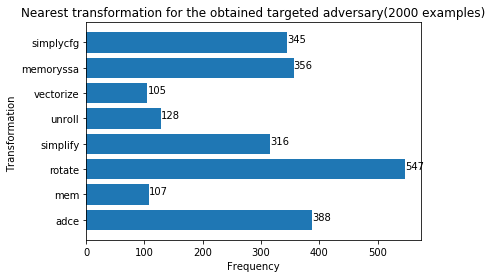

In [32]:
x = ["adce","mem","rotate","simplify","unroll","vectorize","memoryssa","simplycfg"]
y = count
plt.barh(x, y)
plt.ylabel("Transformation ")
plt.xlabel("Frequency")
plt.title("Nearest transformation for the obtained targeted adversary(2000 examples)")

for index, value in enumerate(y):
    plt.text(value, index, str(value))


In [33]:
def printclass1(count,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist):
    if(minimum==poj_dist):
        print("poj")
        count[0]=count[0]+1;
    if(minimum==adce_dist):
        print("adce")
        count[1]=count[1]+1;
    if(minimum==mem2reg_dist):
        print("mem2reg")
        count[2]=count[2]+1;
    if(minimum==loop_rotate_dist):
        print("loop_rotate")
        count[3]=count[3]+1;
    if(minimum==loop_simplify_dist):
        print("loop_simplify")
        count[4]=count[4]+1;
    if(minimum==loop_unroll_dist):
        print("loop_unroll")
        count[5]=count[5]+1;
    if(minimum==loop_vectorize_dist):
        print("loop_vectorize")
        count[6]=count[6]+1;
    if(minimum==memoryssa_dist):
        print("memoryssa")
        count[7]=count[7]+1;
    if(minimum==simplifycfg_dist):
        print("simplifycfg")
        count[8]=count[8]+1;

In [35]:
count3=[0,0,0,0,0,0,0,0,0]
for index in range(subsetsize):
    i=shuffled_index[index]
    poj_dist=np.linalg.norm(x_poj[i] - initial_adversaries1[index])
    adce_dist=np.linalg.norm(x_adce[i] - initial_adversaries1[index])
    mem2reg_dist=np.linalg.norm(x_mem2reg[i] - initial_adversaries1[index])
    loop_rotate_dist=np.linalg.norm(x_loop_rotate[i] - initial_adversaries1[index])
    loop_simplify_dist=np.linalg.norm(x_loop_simplify[i] - initial_adversaries1[index])
    loop_unroll_dist=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[index])
    loop_vectorize_dist=np.linalg.norm(x_loop_vectorize[i] - initial_adversaries1[index])
    memoryssa_dist=np.linalg.norm(x_memoryssa[i] - initial_adversaries1[index])
    simplifycfg_dist=np.linalg.norm(x_simplifycfg[i] - initial_adversaries1[index])
    minimum=min(poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)
    print("For "+str(i)+"  ")
    printclass1(count3,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)

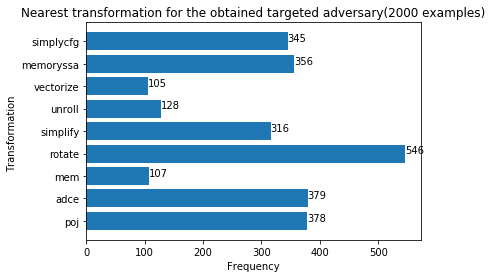

In [37]:
x = ["poj","adce","mem","rotate","simplify","unroll","vectorize","memoryssa","simplycfg"]
y = count3
plt.barh(x, y)
plt.ylabel("Transformation ")
plt.xlabel("Frequency")
plt.title("Nearest transformation for the obtained targeted adversary(2000 examples)")

for index, value in enumerate(y):
    plt.text(value, index, str(value))

Analysis 2-- Pick any random transformed example (considered loop rotate) and consider its label as target,perform attack on actual input

Perform targeted attack

In [38]:
initial_adversaries=[]
increment_value = 10
baseImage = tf.constant(x_poj[0:0+1], dtype=tf.float32)
delta = tf.Variable(tf.zeros_like(baseImage), trainable=True)
for i in range(subsetsize):
    print(i)
    index=shuffled_index[i]
    baseImage = tf.constant(x_poj[index:index+1], dtype=tf.float32)
    delta = tf.Variable(tf.zeros_like(baseImage), trainable=True)
    targer = Y_loop_rotate[index]
    deltaUpdated = generate_targeted_adversaries(model, baseImage, delta,Y_poj[index], targer)
    initial_adversaries.append(deltaUpdated)

0
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1
step: 0, loss: 4.021894931793213...
step: 0, loss: 4.021894931793213...
2
step: 0, loss: 15.81298542022705...
step: 1, loss: 2.5633058547973633...
3
step: 0, loss: 0.0...
step: 0, loss: 0.0...
4
step: 0, loss: 0.0...
step: 0, loss: 0.0...
5
step: 0, loss: 0.0...
step: 0, loss: 0.0...
6
step: 0, loss: 0.0...
step: 0, loss: 0.0...
7
step: 0, loss: 0.0...
step: 0, loss: 0.0...
8
step: 0, loss: 0.0...
step: 0, loss: 0.0...
9
step: 0, loss: 0.0...
step: 0, loss: 0.0...
10
step: 0, loss: 0.0...
step: 0, loss: 0.0...
11
step: 0, loss: 0.0...
step: 0, loss: 0.0...
12
step: 0, loss: 0.0...
step: 0, loss: 0.0...
13
step: 0, loss: 0.0...
step: 0, loss: 0.0...
14
step: 0, loss: 0.0...
step: 0, loss: 0.0...
15
step: 0, loss: 0.0...
step: 0, loss: 0.0...
16
step: 0, loss: 0.0...
step: 0, loss: 0.0...
17
step: 0, loss: 0.0...
step: 0, loss: 0.0...
18
step: 0, loss: 0.0...
step: 0, loss: 0.0...
19
step: 0, loss: 0.0...
step: 0, loss: 0.0...
20
step: 0, l

step: 0, loss: 0.0...
330
step: 0, loss: 0.0...
step: 0, loss: 0.0...
331
step: 0, loss: 0.0...
step: 0, loss: 0.0...
332
step: 0, loss: 0.0...
step: 0, loss: 0.0...
333
step: 0, loss: 0.0...
step: 0, loss: 0.0...
334
step: 0, loss: 0.0...
step: 0, loss: 0.0...
335
step: 0, loss: 0.0...
step: 0, loss: 0.0...
336
step: 0, loss: 0.0...
step: 0, loss: 0.0...
337
step: 0, loss: 12.14560317993164...
step: 10, loss: -15.295976638793945...
step: 10, loss: -15.295976638793945...
338
step: 0, loss: 0.0...
step: 0, loss: 0.0...
339
step: 0, loss: 0.0...
step: 0, loss: 0.0...
340
step: 0, loss: 0.0...
step: 0, loss: 0.0...
341
step: 0, loss: 0.0...
step: 0, loss: 0.0...
342
step: 0, loss: 0.0...
step: 0, loss: 0.0...
343
step: 0, loss: 16.11809539794922...
step: 10, loss: -13.074260711669922...
step: 11, loss: -14.608049392700195...
344
step: 0, loss: 0.0...
step: 0, loss: 0.0...
345
step: 0, loss: 0.0...
step: 0, loss: 0.0...
346
step: 0, loss: 0.0...
step: 0, loss: 0.0...
347
step: 0, loss: 0.0

step: 0, loss: 0.0...
step: 0, loss: 0.0...
491
step: 0, loss: 0.0...
step: 0, loss: 0.0...
492
step: 0, loss: 0.0...
step: 0, loss: 0.0...
493
step: 0, loss: 0.0...
step: 0, loss: 0.0...
494
step: 0, loss: 0.0...
step: 0, loss: 0.0...
495
step: 0, loss: 0.0...
step: 0, loss: 0.0...
496
step: 0, loss: 0.0...
step: 0, loss: 0.0...
497
step: 0, loss: 0.0...
step: 0, loss: 0.0...
498
step: 0, loss: 0.0...
step: 0, loss: 0.0...
499
step: 0, loss: 0.0...
step: 0, loss: 0.0...
500
step: 0, loss: 0.0...
step: 0, loss: 0.0...
501
step: 0, loss: 0.0...
step: 0, loss: 0.0...
502
step: 0, loss: 0.0...
step: 0, loss: 0.0...
503
step: 0, loss: 0.0...
step: 0, loss: 0.0...
504
step: 0, loss: 0.0...
step: 0, loss: 0.0...
505
step: 0, loss: 0.0...
step: 0, loss: 0.0...
506
step: 0, loss: 0.0...
step: 0, loss: 0.0...
507
step: 0, loss: 0.0...
step: 0, loss: 0.0...
508
step: 0, loss: 0.0...
step: 0, loss: 0.0...
509
step: 0, loss: 0.0...
step: 0, loss: 0.0...
510
step: 0, loss: 0.0...
step: 0, loss: 0.0

step: 0, loss: 0.0...
655
step: 0, loss: 0.0...
step: 0, loss: 0.0...
656
step: 0, loss: 0.0...
step: 0, loss: 0.0...
657
step: 0, loss: 0.0...
step: 0, loss: 0.0...
658
step: 0, loss: 0.0...
step: 0, loss: 0.0...
659
step: 0, loss: 0.0...
step: 0, loss: 0.0...
660
step: 0, loss: 0.0...
step: 0, loss: 0.0...
661
step: 0, loss: 0.0...
step: 0, loss: 0.0...
662
step: 0, loss: 0.0...
step: 0, loss: 0.0...
663
step: 0, loss: 0.0...
step: 0, loss: 0.0...
664
step: 0, loss: 14.521618843078613...
step: 10, loss: -9.41352653503418...
step: 14, loss: -14.930047988891602...
665
step: 0, loss: 0.0...
step: 0, loss: 0.0...
666
step: 0, loss: 0.0...
step: 0, loss: 0.0...
667
step: 0, loss: 0.0...
step: 0, loss: 0.0...
668
step: 0, loss: 0.0...
step: 0, loss: 0.0...
669
step: 0, loss: 0.0...
step: 0, loss: 0.0...
670
step: 0, loss: 0.0...
step: 0, loss: 0.0...
671
step: 0, loss: 16.118091583251953...
step: 5, loss: -11.627779006958008...
672
step: 0, loss: 0.0...
step: 0, loss: 0.0...
673
step: 0, l

step: 0, loss: 0.0...
815
step: 0, loss: 0.0...
step: 0, loss: 0.0...
816
step: 0, loss: 0.0...
step: 0, loss: 0.0...
817
step: 0, loss: 0.0...
step: 0, loss: 0.0...
818
step: 0, loss: 0.0...
step: 0, loss: 0.0...
819
step: 0, loss: 0.0...
step: 0, loss: 0.0...
820
step: 0, loss: 0.0...
step: 0, loss: 0.0...
821
step: 0, loss: 0.0...
step: 0, loss: 0.0...
822
step: 0, loss: 0.0...
step: 0, loss: 0.0...
823
step: 0, loss: 0.0...
step: 0, loss: 0.0...
824
step: 0, loss: 0.0...
step: 0, loss: 0.0...
825
step: 0, loss: 7.135486602783203...
step: 2, loss: -5.651399612426758...
826
step: 0, loss: 0.0...
step: 0, loss: 0.0...
827
step: 0, loss: 0.0...
step: 0, loss: 0.0...
828
step: 0, loss: 0.0...
step: 0, loss: 0.0...
829
step: 0, loss: 0.0...
step: 0, loss: 0.0...
830
step: 0, loss: 0.0...
step: 0, loss: 0.0...
831
step: 0, loss: 0.0...
step: 0, loss: 0.0...
832
step: 0, loss: 0.0...
step: 0, loss: 0.0...
833
step: 0, loss: 0.0...
step: 0, loss: 0.0...
834
step: 0, loss: 0.0...
step: 0, lo

...

step: 0, loss: 0.0...
1296
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1297
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1298
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1299
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1300
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1301
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1302
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1303
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1304
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1305
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1306
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1307
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1308
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1309
step: 0, loss: 16.11809539794922...
step: 6, loss: -7.57278299331665...
1310
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1311
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1312
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1313
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1314
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1315
step: 0, loss:

step: 0, loss: 0.0...
1454
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1455
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1456
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1457
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1458
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1459
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1460
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1461
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1462
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1463
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1464
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1465
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1466
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1467
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1468
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1469
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1470
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1471
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1472
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1473
step: 0, loss: 0.0...
step: 0, loss: 0.0..

step: 0, loss: 0.0...
1611
step: 0, loss: 16.118093490600586...
step: 10, loss: -7.3396759033203125...
step: 16, loss: -14.793038368225098...
1612
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1613
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1614
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1615
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1616
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1617
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1618
step: 0, loss: 8.780390739440918...
step: 6, loss: -12.10284423828125...
1619
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1620
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1621
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1622
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1623
step: 0, loss: 8.395757675170898...
step: 0, loss: 8.395757675170898...
1624
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1625
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1626
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1627
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1628
step: 0, los

step: 0, loss: 0.0...
1768
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1769
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1770
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1771
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1772
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1773
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1774
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1775
step: 0, loss: 6.859396934509277...
step: 1, loss: -5.755203723907471...
1776
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1777
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1778
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1779
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1780
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1781
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1782
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1783
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1784
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1785
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1786
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1787
step: 0, loss

step: 0, loss: 0.0...
1930
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1931
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1932
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1933
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1934
step: 0, loss: 16.118078231811523...
step: 10, loss: -11.84967041015625...
step: 12, loss: -14.687788009643555...
1935
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1936
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1937
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1938
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1939
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1940
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1941
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1942
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1943
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1944
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1945
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1946
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1947
step: 0, loss: 0.0...
step: 0, loss: 0.0...
1948
step: 0, loss: 0.0...

In [42]:
for i in range(subsetsize):
    index=shuffled_index[i]
    baseImage = tf.constant(x_poj[index:index+1], dtype=tf.float32)
    targer = Y_loop_rotate[index]
    x_test_1 = baseImage + initial_adversaries[i]
    predicted_y = model.predict_classes(x_test_1, batch_size=32, verbose=2)
    print(Y_poj[index],predicted_y[0], targer)

1/1 - 0s
70 70 70
1/1 - 0s
23 22 22
1/1 - 0s
24 23 23
1/1 - 0s
70 70 70
1/1 - 0s
25 25 25
1/1 - 0s
15 15 15
1/1 - 0s
10 10 10
1/1 - 0s
55 55 55
1/1 - 0s
80 80 80
1/1 - 0s
11 11 11
1/1 - 0s
36 36 36
1/1 - 0s
10 10 10
1/1 - 0s
72 72 72
1/1 - 0s
54 54 54
1/1 - 0s
61 61 61
1/1 - 0s
56 56 56
1/1 - 0s
20 20 20
1/1 - 0s
14 14 14
1/1 - 0s
54 54 54
1/1 - 0s
80 80 80
1/1 - 0s
18 18 18
1/1 - 0s
67 67 67
1/1 - 0s
34 34 34
1/1 - 0s
35 35 35
1/1 - 0s
31 31 31
1/1 - 0s
6 6 6
1/1 - 0s
9 9 9
1/1 - 0s
80 80 80
1/1 - 0s
56 56 56
1/1 - 0s
2 2 2
1/1 - 0s
59 59 59
1/1 - 0s
43 43 43
1/1 - 0s
63 63 63
1/1 - 0s
57 57 57
1/1 - 0s
41 41 41
1/1 - 0s
11 11 11
1/1 - 0s
25 25 25
1/1 - 0s
51 51 51
1/1 - 0s
75 75 75
1/1 - 0s
70 70 70
1/1 - 0s
67 67 67
1/1 - 0s
73 73 73
1/1 - 0s
74 74 74
1/1 - 0s
37 37 37
1/1 - 0s
32 32 32
1/1 - 0s
48 48 48
1/1 - 0s
16 16 16
1/1 - 0s
14 14 14
1/1 - 0s
52 52 52
1/1 - 0s
32 32 32
1/1 - 0s
70 70 70
1/1 - 0s
7 7 7
1/1 - 0s
21 21 21
1/1 - 0s
53 53 53
1/1 - 0s
71 70 70
1/1 - 0s
38 38 38
1/1 

62 61 61
1/1 - 0s
64 64 64
1/1 - 0s
69 69 69
1/1 - 0s
71 71 71
1/1 - 0s
14 14 14
1/1 - 0s
67 66 66
1/1 - 0s
48 48 48
1/1 - 0s
4 4 4
1/1 - 0s
39 39 39
1/1 - 0s
0 0 0
1/1 - 0s
15 15 15
1/1 - 0s
60 60 60
1/1 - 0s
75 75 75
1/1 - 0s
52 52 52
1/1 - 0s
21 21 21
1/1 - 0s
79 79 79
1/1 - 0s
16 16 16
1/1 - 0s
71 71 71
1/1 - 0s
65 65 65
1/1 - 0s
76 75 75
1/1 - 0s
11 11 11
1/1 - 0s
32 32 32
1/1 - 0s
60 60 60
1/1 - 0s
32 32 32
1/1 - 0s
74 74 74
1/1 - 0s
67 67 67
1/1 - 0s
32 32 32
1/1 - 0s
45 45 45
1/1 - 0s
38 38 38
1/1 - 0s
3 3 3
1/1 - 0s
64 64 64
1/1 - 0s
78 78 78
1/1 - 0s
20 20 20
1/1 - 0s
4 4 4
1/1 - 0s
34 34 34
1/1 - 0s
64 64 64
1/1 - 0s
26 26 26
1/1 - 0s
34 34 34
1/1 - 0s
77 77 77
1/1 - 0s
68 68 68
1/1 - 0s
77 77 77
1/1 - 0s
21 21 21
1/1 - 0s
22 22 22
1/1 - 0s
56 56 56
1/1 - 0s
44 44 44
1/1 - 0s
77 77 77
1/1 - 0s
54 54 54
1/1 - 0s
48 48 48
1/1 - 0s
19 19 19
1/1 - 0s
44 44 44
1/1 - 0s
72 72 72
1/1 - 0s
0 0 0
1/1 - 0s
28 28 28
1/1 - 0s
55 55 55
1/1 - 0s
40 40 40
1/1 - 0s
15 15 15
1/1 - 0s
49 49 4

34 34 34
1/1 - 0s
40 40 40
1/1 - 0s
50 50 50
1/1 - 0s
44 44 44
1/1 - 0s
30 29 29
1/1 - 0s
28 28 28
1/1 - 0s
26 26 26
1/1 - 0s
59 59 59
1/1 - 0s
73 73 73
1/1 - 0s
16 16 16
1/1 - 0s
31 31 31
1/1 - 0s
5 5 5
1/1 - 0s
40 40 40
1/1 - 0s
31 31 31
1/1 - 0s
16 16 16
1/1 - 0s
33 33 33
1/1 - 0s
42 42 42
1/1 - 0s
49 49 49
1/1 - 0s
45 45 45
1/1 - 0s
41 41 41
1/1 - 0s
5 5 5
1/1 - 0s
65 65 65
1/1 - 0s
12 12 12
1/1 - 0s
7 7 7
1/1 - 0s
37 37 37
1/1 - 0s
3 3 3
1/1 - 0s
8 8 8
1/1 - 0s
45 45 45
1/1 - 0s
62 62 62
1/1 - 0s
42 42 42
1/1 - 0s
28 28 28
1/1 - 0s
24 24 24
1/1 - 0s
62 61 61
1/1 - 0s
30 30 30
1/1 - 0s
54 54 54
1/1 - 0s
66 65 65
1/1 - 0s
77 77 77
1/1 - 0s
26 26 26
1/1 - 0s
15 15 15
1/1 - 0s
10 10 10
1/1 - 0s
37 37 37
1/1 - 0s
65 65 65
1/1 - 0s
10 10 10
1/1 - 0s
53 53 53
1/1 - 0s
73 73 73
1/1 - 0s
56 56 56
1/1 - 0s
44 44 44
1/1 - 0s
67 67 67
1/1 - 0s
37 37 37
1/1 - 0s
61 61 61
1/1 - 0s
37 37 37
1/1 - 0s
26 26 26
1/1 - 0s
70 69 69
1/1 - 0s
21 21 21
1/1 - 0s
7 7 7
1/1 - 0s
4 4 4
1/1 - 0s
38 38 38
1/1 

58 57 57
1/1 - 0s
4 4 4
1/1 - 0s
62 62 62
1/1 - 0s
11 11 11
1/1 - 0s
43 43 43
1/1 - 0s
33 32 32
1/1 - 0s
65 65 65
1/1 - 0s
49 49 49
1/1 - 0s
40 40 40
1/1 - 0s
60 60 60
1/1 - 0s
29 29 29
1/1 - 0s
28 28 28
1/1 - 0s
62 62 62
1/1 - 0s
70 70 70
1/1 - 0s
62 61 61
1/1 - 0s
25 25 25
1/1 - 0s
51 51 51
1/1 - 0s
20 20 20
1/1 - 0s
2 2 2
1/1 - 0s
15 15 15
1/1 - 0s
64 64 64
1/1 - 0s
26 26 26
1/1 - 0s
8 8 8
1/1 - 0s
8 8 8
1/1 - 0s
72 72 72
1/1 - 0s
23 23 23
1/1 - 0s
4 4 4
1/1 - 0s
80 80 80
1/1 - 0s
68 68 68
1/1 - 0s
4 4 4
1/1 - 0s
60 60 60
1/1 - 0s
32 32 32
1/1 - 0s
66 66 66
1/1 - 0s
10 10 10
1/1 - 0s
36 36 36
1/1 - 0s
51 51 51
1/1 - 0s
58 58 58
1/1 - 0s
2 2 2
1/1 - 0s
69 69 69
1/1 - 0s
16 16 16
1/1 - 0s
64 64 64
1/1 - 0s
8 8 8
1/1 - 0s
50 50 50
1/1 - 0s
30 30 30
1/1 - 0s
77 77 77
1/1 - 0s
74 74 74
1/1 - 0s
50 50 50
1/1 - 0s
43 43 43
1/1 - 0s
58 58 58
1/1 - 0s
49 49 49
1/1 - 0s
68 67 67
1/1 - 0s
23 23 23
1/1 - 0s
33 33 33
1/1 - 0s
43 43 43
1/1 - 0s
34 34 34
1/1 - 0s
36 36 36
1/1 - 0s
5 5 5
1/1 - 0s
1

1 1 1
1/1 - 0s
20 20 20
1/1 - 0s
66 66 66
1/1 - 0s
51 51 51
1/1 - 0s
31 31 31
1/1 - 0s
28 28 28
1/1 - 0s
63 63 63
1/1 - 0s
47 47 47
1/1 - 0s
7 7 7
1/1 - 0s
42 42 42
1/1 - 0s
31 31 31
1/1 - 0s
35 35 35
1/1 - 0s
28 28 28
1/1 - 0s
62 62 62
1/1 - 0s
16 16 16
1/1 - 0s
1 1 1
1/1 - 0s
17 17 17
1/1 - 0s
54 54 54
1/1 - 0s
29 29 29
1/1 - 0s
58 58 58
1/1 - 0s
54 54 54
1/1 - 0s
28 28 28
1/1 - 0s
19 19 19
1/1 - 0s
66 66 66
1/1 - 0s
11 11 11
1/1 - 0s
66 66 66
1/1 - 0s
12 12 12
1/1 - 0s
42 42 42
1/1 - 0s
7 7 7
1/1 - 0s
5 5 5
1/1 - 0s
79 79 79
1/1 - 0s
8 8 8
1/1 - 0s
40 40 40
1/1 - 0s
5 5 5
1/1 - 0s
51 51 51
1/1 - 0s
59 59 59
1/1 - 0s
67 67 67
1/1 - 0s
32 32 32
1/1 - 0s
79 78 78
1/1 - 0s
12 12 12
1/1 - 0s
72 72 72
1/1 - 0s
52 52 52
1/1 - 0s
51 50 50
1/1 - 0s
21 20 20
1/1 - 0s
34 34 34
1/1 - 0s
53 53 53
1/1 - 0s
45 45 45
1/1 - 0s
71 71 71
1/1 - 0s
0 0 0
1/1 - 0s
43 43 43
1/1 - 0s
29 29 29
1/1 - 0s
49 49 49
1/1 - 0s
69 69 69
1/1 - 0s
41 41 41
1/1 - 0s
13 13 13
1/1 - 0s
13 13 13
1/1 - 0s
71 71 71
1/1 - 0

In [43]:
def printclass(count,minimum,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist):
    if(minimum==adce_dist):
        print("adce")
        count[0]=count[0]+1;
    if(minimum==mem2reg_dist):
        print("mem2reg")
        count[1]=count[1]+1;
    if(minimum==loop_rotate_dist):
        print("loop_rotate")
        count[2]=count[2]+1;
    if(minimum==loop_simplify_dist):
        print("loop_simplify")
        count[3]=count[3]+1;
    if(minimum==loop_unroll_dist):
        print("loop_unroll")
        count[4]=count[4]+1;
    if(minimum==loop_vectorize_dist):
        print("loop_vectorize")
        count[5]=count[5]+1;
    if(minimum==memoryssa_dist):
        print("memoryssa")
        count[6]=count[6]+1;
    if(minimum==simplifycfg_dist):
        print("simplifycfg")
        count[7]=count[7]+1;

In [44]:
count=[0,0,0,0,0,0,0,0]
for index in range(subsetsize):
    i=shuffled_index[index]
    adce_dist=np.linalg.norm(x_adce[i] - initial_adversaries1[index])
    mem2reg_dist=np.linalg.norm(x_mem2reg[i] - initial_adversaries1[index])
    loop_rotate_dist=np.linalg.norm(x_loop_rotate[i] - initial_adversaries1[index])
    loop_simplify_dist=np.linalg.norm(x_loop_simplify[i] - initial_adversaries1[index])
    loop_unroll_dist=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[index])
    loop_vectorize_dist=np.linalg.norm(x_loop_vectorize[i] - initial_adversaries1[index])
    memoryssa_dist=np.linalg.norm(x_memoryssa[i] - initial_adversaries1[index])
    simplifycfg_dist=np.linalg.norm(x_simplifycfg[i] - initial_adversaries1[index])
    minimum=min(adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)
    print("For "+str(index)+"  ")
    printclass(count,minimum,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)

For 0  
loop_rotate
For 1  
memoryssa
For 2  
loop_rotate
For 3  
loop_vectorize
For 4  
loop_rotate
For 5  
loop_rotate
For 6  
loop_unroll
For 7  
loop_unroll
For 8  
loop_simplify
For 9  
simplifycfg
For 10  
simplifycfg
For 11  
mem2reg
For 12  
simplifycfg
For 13  
adce
For 14  
loop_unroll
For 15  
memoryssa
For 16  
simplifycfg
For 17  
simplifycfg
For 18  
mem2reg
For 19  
adce
For 20  
loop_rotate
For 21  
simplifycfg
For 22  
simplifycfg
For 23  
loop_rotate
For 24  
adce
For 25  
loop_rotate
For 26  
adce
loop_simplify
memoryssa
For 27  
simplifycfg
For 28  
adce
loop_simplify
For 29  
loop_rotate
For 30  
loop_rotate
For 31  
adce
For 32  
simplifycfg
For 33  
memoryssa
For 34  
simplifycfg
For 35  
loop_rotate
For 36  
mem2reg
For 37  
loop_unroll
For 38  
adce
For 39  
adce
For 40  
memoryssa
For 41  
simplifycfg
For 42  
memoryssa
For 43  
loop_rotate
For 44  
loop_simplify
memoryssa
For 45  
memoryssa
For 46  
simplifycfg
For 47  
adce
loop_simplify
memoryssa
For 48  
a

loop_rotate
For 919  
memoryssa
For 920  
memoryssa
For 921  
loop_simplify
For 922  
loop_vectorize
For 923  
loop_unroll
For 924  
loop_vectorize
For 925  
loop_simplify
For 926  
adce
For 927  
adce
For 928  
memoryssa
For 929  
loop_rotate
For 930  
adce
loop_simplify
For 931  
loop_rotate
For 932  
loop_rotate
For 933  
adce
For 934  
loop_simplify
memoryssa
For 935  
simplifycfg
For 936  
loop_simplify
For 937  
loop_rotate
For 938  
adce
For 939  
loop_rotate
For 940  
simplifycfg
For 941  
loop_simplify
memoryssa
For 942  
loop_rotate
For 943  
loop_simplify
For 944  
simplifycfg
For 945  
memoryssa
For 946  
simplifycfg
For 947  
adce
For 948  
simplifycfg
For 949  
loop_rotate
For 950  
loop_unroll
For 951  
mem2reg
For 952  
loop_rotate
For 953  
loop_rotate
For 954  
loop_rotate
For 955  
adce
For 956  
memoryssa
For 957  
adce
For 958  
loop_vectorize
For 959  
loop_rotate
For 960  
adce
loop_simplify
For 961  
loop_rotate
For 962  
simplifycfg
For 963  
simplifycfg
For 96

For 1846  
loop_rotate
For 1847  
adce
loop_simplify
memoryssa
For 1848  
mem2reg
For 1849  
loop_rotate
For 1850  
adce
For 1851  
loop_unroll
For 1852  
loop_simplify
memoryssa
For 1853  
loop_simplify
For 1854  
loop_vectorize
For 1855  
adce
For 1856  
loop_rotate
For 1857  
mem2reg
For 1858  
loop_rotate
For 1859  
loop_simplify
For 1860  
simplifycfg
For 1861  
loop_simplify
memoryssa
For 1862  
adce
loop_simplify
For 1863  
memoryssa
For 1864  
simplifycfg
For 1865  
loop_vectorize
For 1866  
mem2reg
For 1867  
loop_vectorize
For 1868  
mem2reg
For 1869  
loop_rotate
For 1870  
loop_simplify
memoryssa
For 1871  
memoryssa
For 1872  
loop_simplify
memoryssa
For 1873  
simplifycfg
For 1874  
adce
loop_simplify
memoryssa
For 1875  
loop_unroll
For 1876  
mem2reg
For 1877  
memoryssa
For 1878  
simplifycfg
For 1879  
mem2reg
For 1880  
memoryssa
For 1881  
loop_rotate
For 1882  
loop_rotate
For 1883  
loop_rotate
For 1884  
loop_rotate
For 1885  
mem2reg
For 1886  
loop_vectorize
Fo

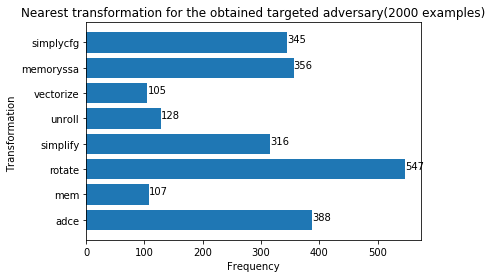

In [45]:
x = ["adce","mem","rotate","simplify","unroll","vectorize","memoryssa","simplycfg"]
y = count
plt.barh(x, y)
plt.ylabel("Transformation ")
plt.xlabel("Frequency")
plt.title("Nearest transformation for the obtained targeted adversary(2000 examples)")

for index, value in enumerate(y):
    plt.text(value, index, str(value))

In [46]:
def printclass1(count,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist):
    if(minimum==poj_dist):
        print("poj")
        count[0]=count[0]+1;
    if(minimum==adce_dist):
        print("adce")
        count[1]=count[1]+1;
    if(minimum==mem2reg_dist):
        print("mem2reg")
        count[2]=count[2]+1;
    if(minimum==loop_rotate_dist):
        print("loop_rotate")
        count[3]=count[3]+1;
    if(minimum==loop_simplify_dist):
        print("loop_simplify")
        count[4]=count[4]+1;
    if(minimum==loop_unroll_dist):
        print("loop_unroll")
        count[5]=count[5]+1;
    if(minimum==loop_vectorize_dist):
        print("loop_vectorize")
        count[6]=count[6]+1;
    if(minimum==memoryssa_dist):
        print("memoryssa")
        count[7]=count[7]+1;
    if(minimum==simplifycfg_dist):
        print("simplifycfg")
        count[8]=count[8]+1;

In [47]:
count3=[0,0,0,0,0,0,0,0,0]
for index in range(subsetsize):
    i=shuffled_index[index]
    poj_dist=np.linalg.norm(x_poj[i] - initial_adversaries1[index])
    adce_dist=np.linalg.norm(x_adce[i] - initial_adversaries1[index])
    mem2reg_dist=np.linalg.norm(x_mem2reg[i] - initial_adversaries1[index])
    loop_rotate_dist=np.linalg.norm(x_loop_rotate[i] - initial_adversaries1[index])
    loop_simplify_dist=np.linalg.norm(x_loop_simplify[i] - initial_adversaries1[index])
    loop_unroll_dist=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[index])
    loop_vectorize_dist=np.linalg.norm(x_loop_vectorize[i] - initial_adversaries1[index])
    memoryssa_dist=np.linalg.norm(x_memoryssa[i] - initial_adversaries1[index])
    simplifycfg_dist=np.linalg.norm(x_simplifycfg[i] - initial_adversaries1[index])
    minimum=min(poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)
    print("For "+str(i)+"  ")
    printclass1(count3,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)

For 27854  
loop_rotate
For 9072  
memoryssa
For 9242  
loop_rotate
For 27672  
loop_vectorize
For 9795  
loop_rotate
For 6662  
loop_rotate
For 4285  
loop_unroll
For 21838  
loop_unroll
For 32046  
loop_simplify
For 4769  
simplifycfg
For 13861  
simplifycfg
For 4327  
mem2reg
For 28643  
simplifycfg
For 21210  
poj
adce
For 23940  
loop_unroll
For 22072  
memoryssa
For 8062  
simplifycfg
For 6009  
simplifycfg
For 21184  
mem2reg
For 31976  
poj
For 7572  
loop_rotate
For 26450  
simplifycfg
For 12802  
simplifycfg
For 13352  
loop_rotate
For 11499  
poj
adce
For 2760  
loop_rotate
For 4045  
poj
adce
loop_simplify
memoryssa
For 32097  
simplifycfg
For 21936  
poj
adce
loop_simplify
For 1110  
loop_rotate
For 23289  
loop_rotate
For 16636  
poj
adce
For 24714  
simplifycfg
For 22413  
memoryssa
For 15619  
simplifycfg
For 4750  
loop_rotate
For 9738  
mem2reg
For 19928  
loop_unroll
For 29906  
adce
For 27618  
poj
adce
For 26560  
memoryssa
For 28921  
simplifycfg
For 29357  
memor

For 31872  
memoryssa
For 17840  
loop_vectorize
For 9675  
loop_rotate
For 5330  
loop_rotate
For 17475  
mem2reg
For 12986  
memoryssa
For 7513  
simplifycfg
For 13896  
simplifycfg
For 27924  
loop_unroll
For 2314  
poj
adce
loop_simplify
memoryssa
For 18514  
loop_unroll
For 12179  
poj
adce
For 3335  
simplifycfg
For 14206  
loop_simplify
memoryssa
For 19141  
poj
adce
loop_simplify
For 11112  
loop_simplify
memoryssa
For 2544  
loop_vectorize
For 29621  
loop_rotate
For 9880  
loop_rotate
For 31439  
loop_rotate
For 13499  
loop_rotate
For 21161  
simplifycfg
For 18156  
loop_simplify
memoryssa
For 5503  
poj
adce
loop_simplify
memoryssa
For 31611  
loop_simplify
For 3480  
loop_unroll
For 613  
simplifycfg
For 23099  
loop_rotate
For 4325  
loop_vectorize
For 29137  
poj
adce
For 22586  
mem2reg
For 7098  
simplifycfg
For 28966  
simplifycfg
For 19803  
loop_vectorize
For 7350  
simplifycfg
For 8841  
memoryssa
For 21845  
loop_unroll
For 12910  
poj
adce
For 4624  
loop_rotate


For 31503  
poj
adce
For 3543  
simplifycfg
For 15273  
poj
adce
For 2526  
loop_unroll
For 19943  
poj
adce
loop_simplify
For 23043  
loop_rotate
For 26457  
loop_rotate
For 12099  
loop_rotate
For 31457  
loop_simplify
For 5413  
loop_unroll
For 28576  
poj
adce
For 20410  
loop_rotate
For 19634  
adce
For 8480  
simplifycfg
For 12795  
loop_simplify
memoryssa
For 21007  
loop_rotate
For 17599  
simplifycfg
For 28004  
memoryssa
For 212  
mem2reg
For 16544  
poj
adce
For 11312  
loop_rotate
For 19176  
simplifycfg
For 27132  
memoryssa
For 15927  
simplifycfg
For 5627  
loop_rotate
For 5719  
loop_rotate
For 28067  
loop_vectorize
For 30738  
simplifycfg
For 23087  
loop_rotate
For 29354  
poj
adce
For 25034  
poj
adce
loop_simplify
For 26167  
memoryssa
For 30175  
mem2reg
For 26267  
memoryssa
For 21921  
poj
loop_simplify
For 31420  
poj
adce
For 3769  
loop_rotate
For 19203  
loop_vectorize
For 521  
simplifycfg
For 20130  
loop_rotate
For 30201  
poj
adce
For 14300  
poj
adce
Fo

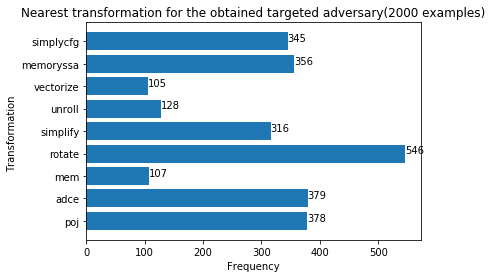

In [48]:
x = ["poj","adce","mem","rotate","simplify","unroll","vectorize","memoryssa","simplycfg"]
y = count3
plt.barh(x, y)
plt.ylabel("Transformation ")
plt.xlabel("Frequency")
plt.title("Nearest transformation for the obtained targeted adversary(2000 examples)")

for index, value in enumerate(y):
    plt.text(value, index, str(value))

In [14]:
def printclass1(count,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist):
    if(minimum==poj_dist):
        print("poj")
        count[0]=count[0]+1;
    if(minimum==adce_dist):
        print("adce")
        count[1]=count[1]+1;
    if(minimum==mem2reg_dist):
        print("mem2reg")
        count[2]=count[2]+1;
    if(minimum==loop_rotate_dist):
        print("loop_rotate")
        count[3]=count[3]+1;
    if(minimum==loop_simplify_dist):
        print("loop_simplify")
        count[4]=count[4]+1;
    if(minimum==loop_unroll_dist):
        print("loop_unroll")
        count[5]=count[5]+1;
    if(minimum==loop_vectorize_dist):
        print("loop_vectorize")
        count[6]=count[6]+1;
    if(minimum==memoryssa_dist):
        print("memoryssa")
        count[7]=count[7]+1;
    if(minimum==simplifycfg_dist):
        print("simplifycfg")
        count[8]=count[8]+1;

In [15]:
count3=[0,0,0,0,0,0,0,0,0]
for index in range(subsetsize):
    i=shuffled_index[index]
    poj_dist=np.linalg.norm(x_poj[i] - initial_adversaries1[index])
    adce_dist=np.linalg.norm(x_adce[i] - initial_adversaries1[index])
    mem2reg_dist=np.linalg.norm(x_mem2reg[i] - initial_adversaries1[index])
    loop_rotate_dist=np.linalg.norm(x_loop_rotate[i] - initial_adversaries1[index])
    loop_simplify_dist=np.linalg.norm(x_loop_simplify[i] - initial_adversaries1[index])
    loop_unroll_dist=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[index])
    loop_vectorize_dist=np.linalg.norm(x_loop_vectorize[i] - initial_adversaries1[index])
    memoryssa_dist=np.linalg.norm(x_memoryssa[i] - initial_adversaries1[index])
    simplifycfg_dist=np.linalg.norm(x_simplifycfg[i] - initial_adversaries1[index])
    minimum=min(poj_dist,adce_dist,mem2reg_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)
    print("For "+str(i)+"  ")
    printclass1(count3,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)

For 27854  
loop_simplify
For 9072  
memoryssa
For 9242  
simplifycfg
For 27672  
memoryssa
For 9795  
loop_unroll
For 6662  
loop_unroll
For 4285  
loop_unroll
For 21838  
loop_unroll
For 32046  
loop_vectorize
For 4769  
mem2reg
For 13861  
mem2reg
For 4327  
mem2reg
For 28643  
simplifycfg
For 21210  
mem2reg
For 23940  
loop_unroll
For 22072  
simplifycfg
For 8062  
loop_vectorize
For 6009  
simplifycfg
For 21184  
mem2reg
For 31976  
poj
For 7572  
simplifycfg
For 26450  
poj
adce
For 12802  
poj
adce
For 13352  
loop_simplify
For 11499  
loop_vectorize
For 2760  
simplifycfg
For 4045  
poj
adce
loop_simplify
memoryssa
For 32097  
poj
adce
For 21936  
memoryssa
For 1110  
loop_simplify
For 23289  
memoryssa
For 16636  
poj
adce
For 24714  
simplifycfg
For 22413  
mem2reg
For 15619  
simplifycfg
For 4750  
loop_vectorize
For 9738  
poj
adce
For 19928  
poj
adce
loop_simplify
For 29906  
loop_unroll
For 27618  
memoryssa
For 26560  
memoryssa
For 28921  
poj
adce
For 29357  
memorys

loop_simplify
For 1005  
poj
adce
memoryssa
For 28824  
loop_vectorize
For 22699  
simplifycfg
For 28763  
memoryssa
For 10302  
loop_vectorize
For 4319  
simplifycfg
For 18192  
simplifycfg
For 8823  
poj
adce
For 3879  
loop_unroll
For 31723  
poj
adce
For 20690  
loop_vectorize
For 3784  
poj
adce
loop_simplify
memoryssa
For 4213  
mem2reg
For 874  
loop_unroll
For 14091  
mem2reg
For 27402  
loop_simplify
For 31114  
loop_vectorize
For 4530  
simplifycfg
For 15483  
loop_vectorize
For 13759  
poj
adce
For 3012  
poj
adce
loop_simplify
memoryssa
For 16089  
poj
adce
For 21069  
adce
For 11461  
loop_vectorize
For 22991  
simplifycfg
For 1435  
loop_unroll
For 12546  
loop_simplify
memoryssa
For 4797  
loop_unroll
For 29069  
loop_simplify
For 10025  
loop_unroll
For 3410  
loop_unroll
For 2543  
loop_unroll
For 11602  
poj
adce
For 4963  
poj
memoryssa
For 23312  
memoryssa
For 27864  
simplifycfg
For 10021  
mem2reg
For 27628  
loop_unroll
For 15539  
mem2reg
For 31025  
memoryssa


For 8584  
poj
adce
For 30309  
poj
adce
For 12171  
simplifycfg
For 15520  
simplifycfg
For 29088  
loop_simplify
For 29929  
mem2reg
For 8737  
loop_simplify
memoryssa
For 12178  
loop_vectorize
For 17435  
loop_vectorize
For 18663  
adce
For 20360  
poj
adce
loop_simplify
For 28568  
simplifycfg
For 21893  
simplifycfg
For 23680  
mem2reg
For 11104  
simplifycfg
For 20820  
loop_vectorize
For 12852  
mem2reg
For 6133  
simplifycfg
For 7599  
loop_simplify
memoryssa
For 31427  
mem2reg
For 4836  
loop_vectorize
For 2773  
mem2reg
For 6788  
loop_vectorize
For 26616  
memoryssa
For 1872  
loop_unroll
For 13608  
poj
adce
For 18052  
loop_simplify
memoryssa
For 12468  
simplifycfg
For 3392  
poj
adce
loop_simplify
memoryssa
For 5388  
loop_vectorize
For 4498  
loop_vectorize
For 31354  
loop_simplify
For 28969  
loop_vectorize
For 14244  
poj
adce
For 15992  
loop_simplify
memoryssa
For 26704  
poj
adce
loop_simplify
For 7853  
loop_simplify
memoryssa
For 24501  
loop_vectorize
For 250

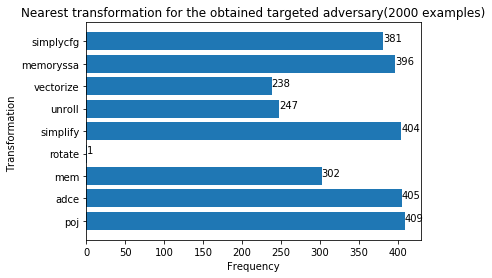

In [16]:
x = ["poj","adce","mem","rotate","simplify","unroll","vectorize","memoryssa","simplycfg"]
y = count3
plt.barh(x, y)
plt.ylabel("Transformation ")
plt.xlabel("Frequency")
plt.title("Nearest transformation for the obtained targeted adversary(2000 examples)")

for index, value in enumerate(y):
    plt.text(value, index, str(value))